# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [76]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  10.9M      0 --:--:--  0:01:20 --:--:-- 18.2M3M      0 --:--:--  0:00:04 --:--:-- 10.3M:00:35 --:--:-- 10.2M--  0:00:55 --:--:-- 7463k


In [71]:
!rm SUSY.csv

In [77]:
!gunzip SUSY.csv.gz

In [72]:
ls -lh

total 17048
-rw-r--r--@ 1 anoob  staff   376K Mar 27 11:13 Lab.7.ipynb
-rw-r--r--@ 1 anoob  staff   8.0M Mar 24 12:04 Lab.7.pdf
-rw-r--r--@ 1 anoob  staff     0B Mar 27 10:54 SUSY-small.csv


The data is provided as a comma separated file.

In [78]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [74]:
!ls -lh

total 17048
-rw-r--r--@ 1 anoob  staff   376K Mar 27 11:13 Lab.7.ipynb
-rw-r--r--@ 1 anoob  staff   8.0M Mar 24 12:04 Lab.7.pdf
-rw-r--r--@ 1 anoob  staff     0B Mar 27 10:54 SUSY-small.csv


We see that we have 5 million datapoints.

In [79]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [80]:
!head -50000 SUSY.csv > SUSY-small.csv

In [81]:
ls -lh

total 4744472
-rw-r--r--@ 1 anoob  staff   375K Mar 27 11:18 Lab.7.ipynb
-rw-r--r--@ 1 anoob  staff   8.0M Mar 24 12:04 Lab.7.pdf
-rw-r--r--@ 1 anoob  staff    23M Mar 27 11:20 SUSY-small.csv
-rw-r--r--@ 1 anoob  staff   2.2G Mar 27 11:16 SUSY.csv


In [82]:
! wc -l SUSY-small.csv

   50000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [83]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [84]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [85]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [86]:
FeatureNames

['dPhi_r_b',
 'axial_MET',
 'cos_theta_r1',
 'MET_rel',
 'S_R',
 'R',
 'M_R',
 'M_TR_2',
 'MT2',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [88]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [89]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [90]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


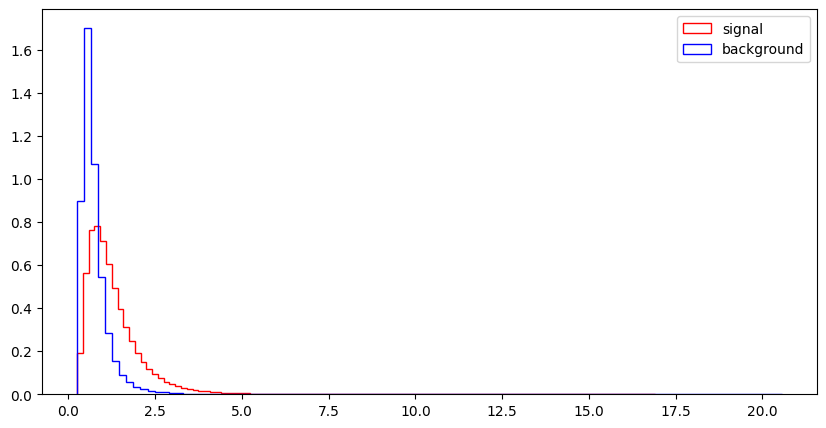

l_1_eta


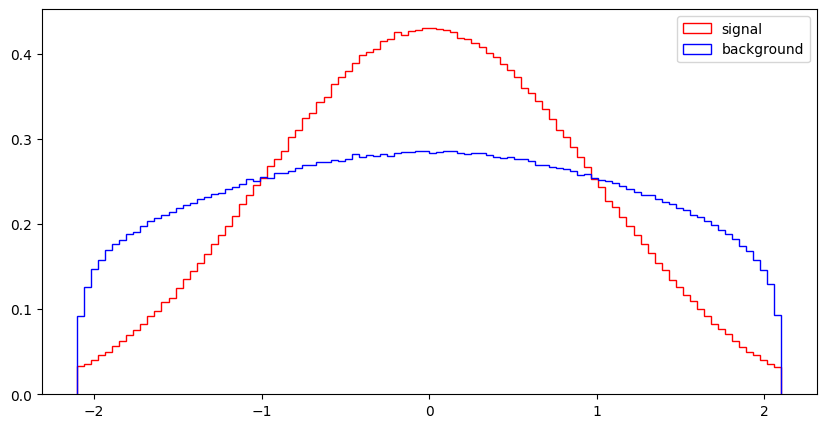

l_1_phi


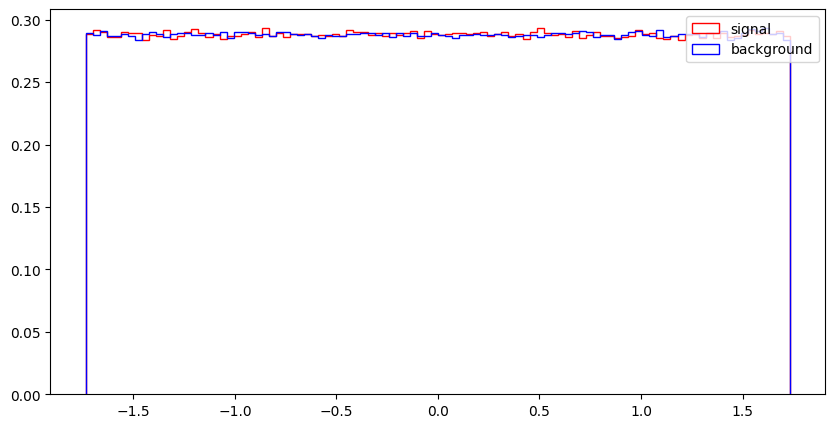

l_2_pT


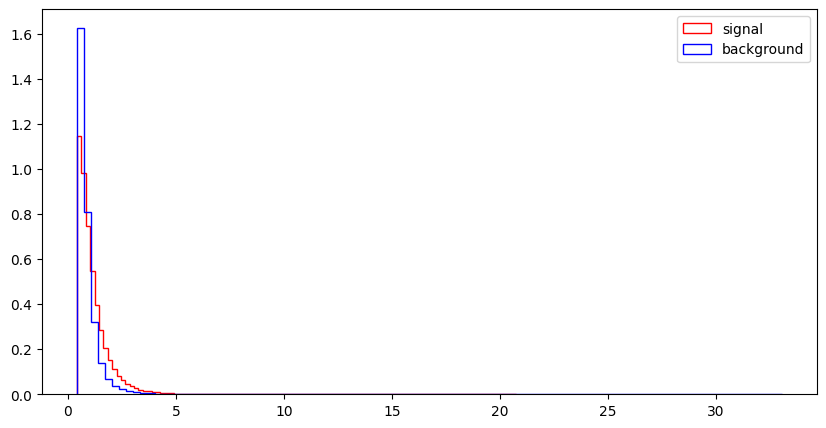

l_2_eta


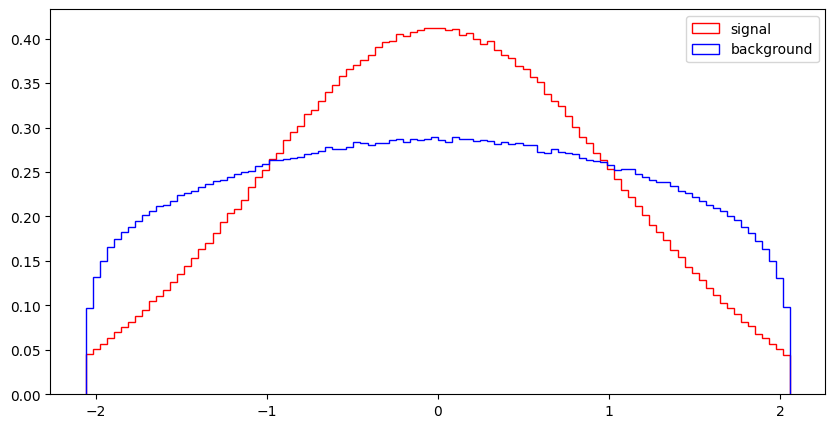

l_2_phi


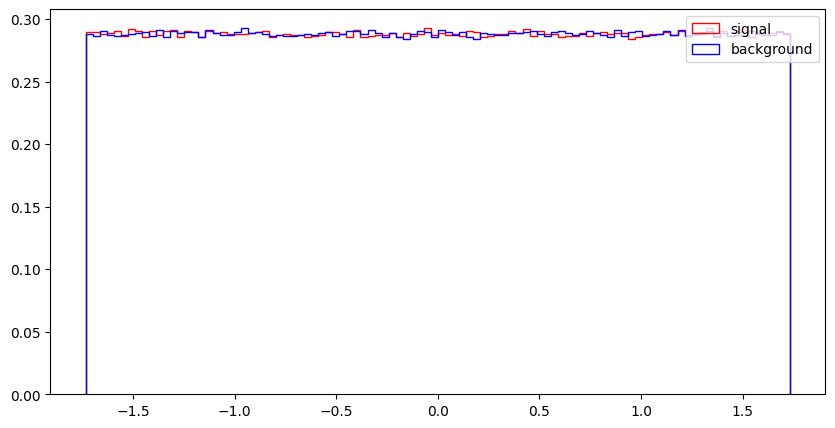

MET


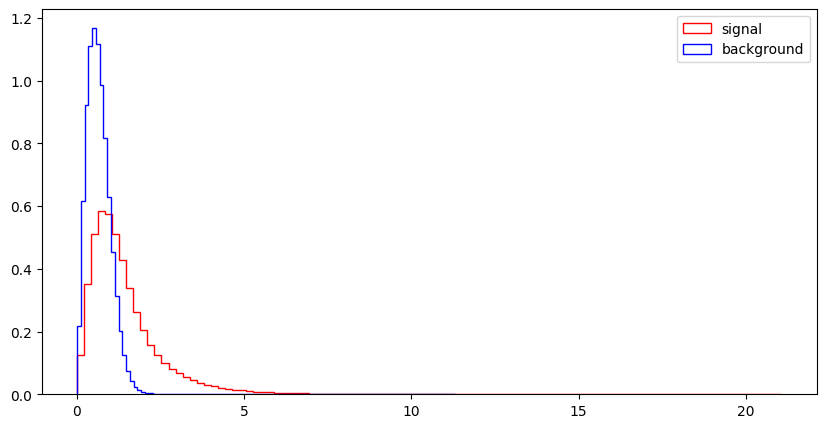

MET_phi


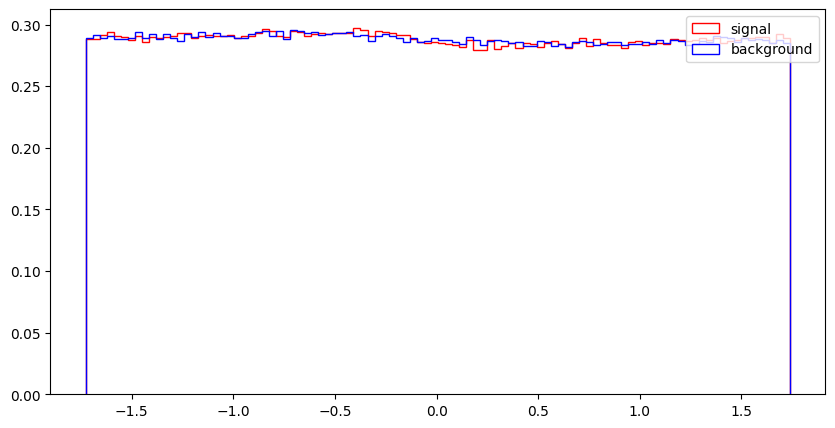

MET_rel


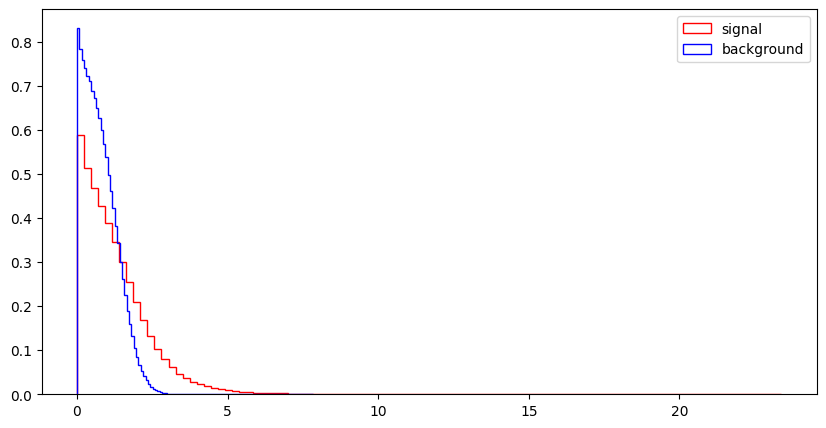

axial_MET


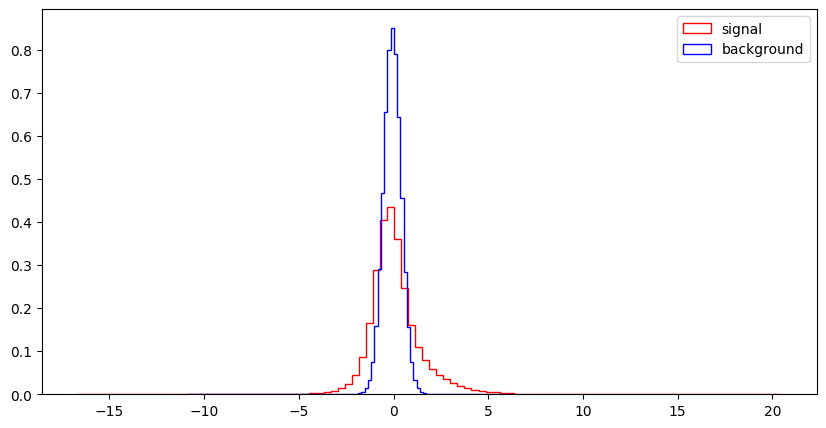

M_R


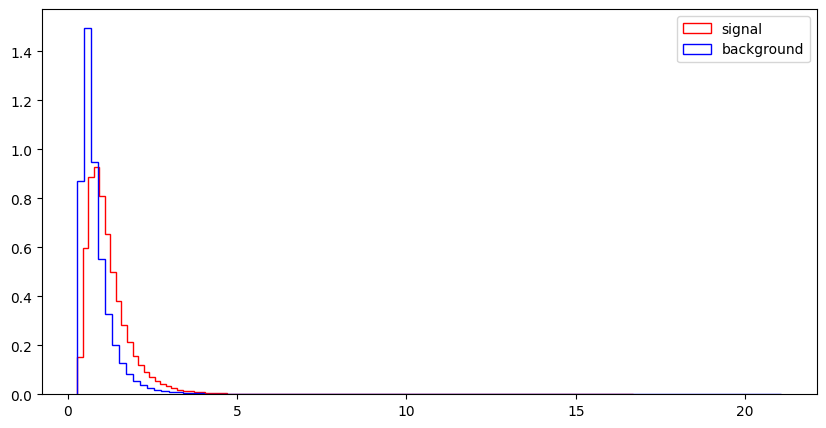

M_TR_2


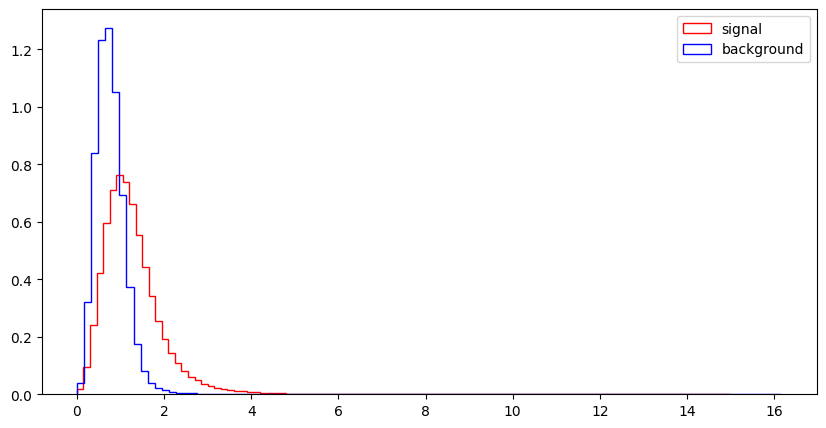

R


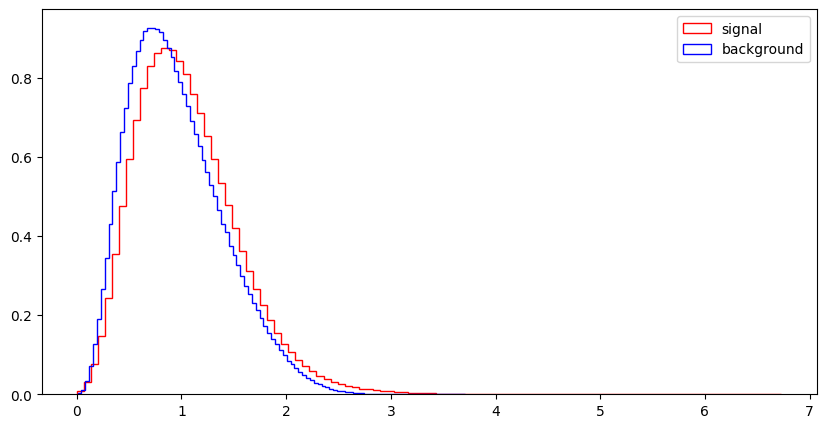

MT2


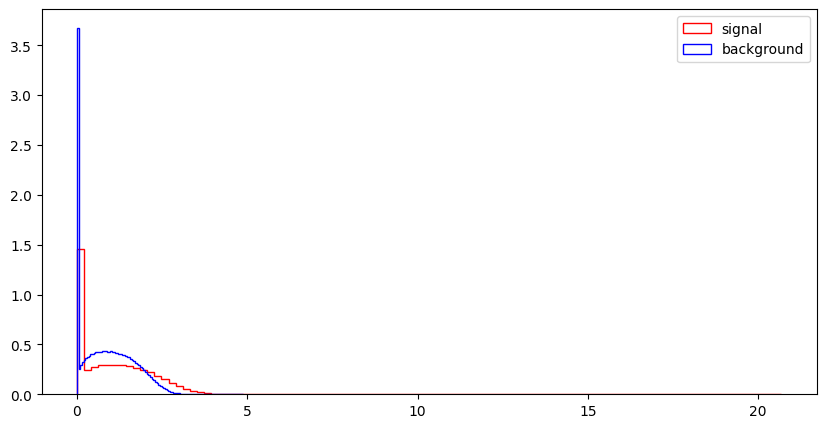

S_R


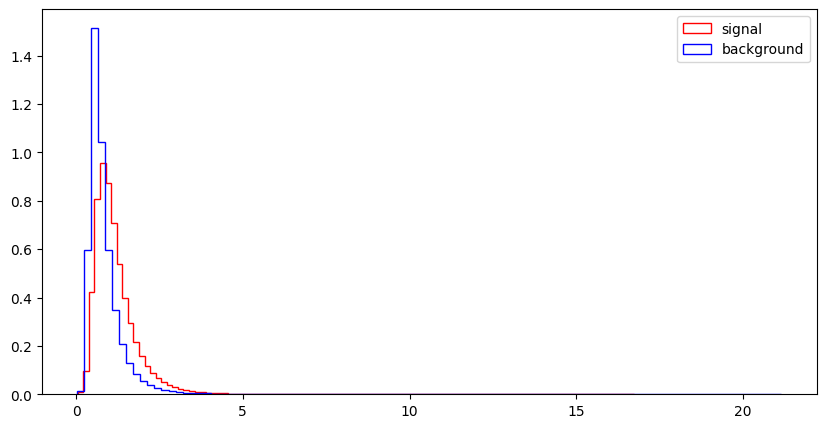

M_Delta_R


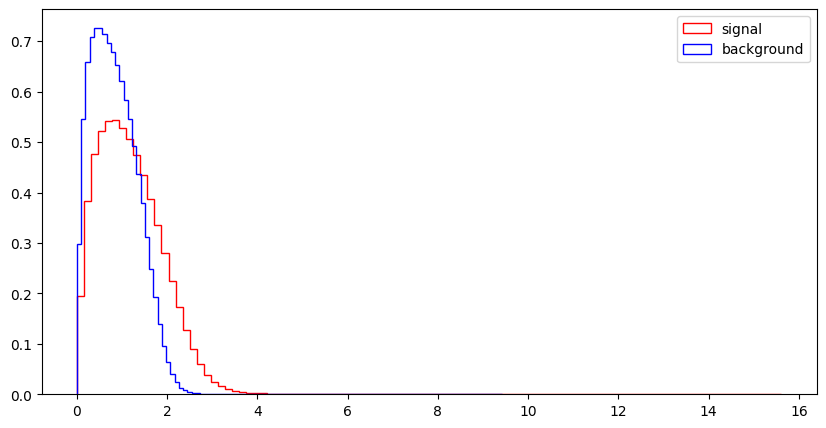

dPhi_r_b


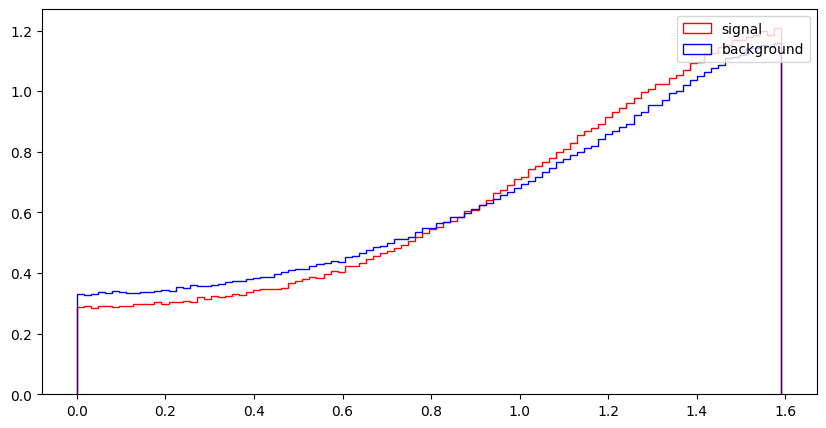

cos_theta_r1


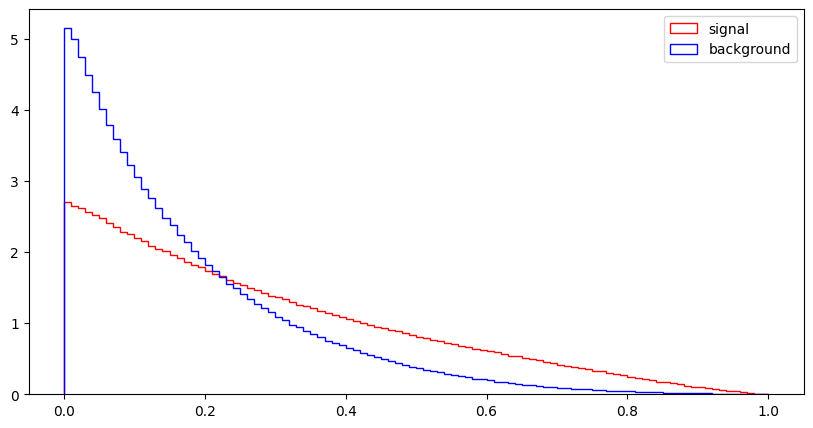

In [91]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import tabulate
%matplotlib inline

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R",
            "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

df = pd.read_csv("SUSY-small.csv", dtype='float64', names=VarNames)
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

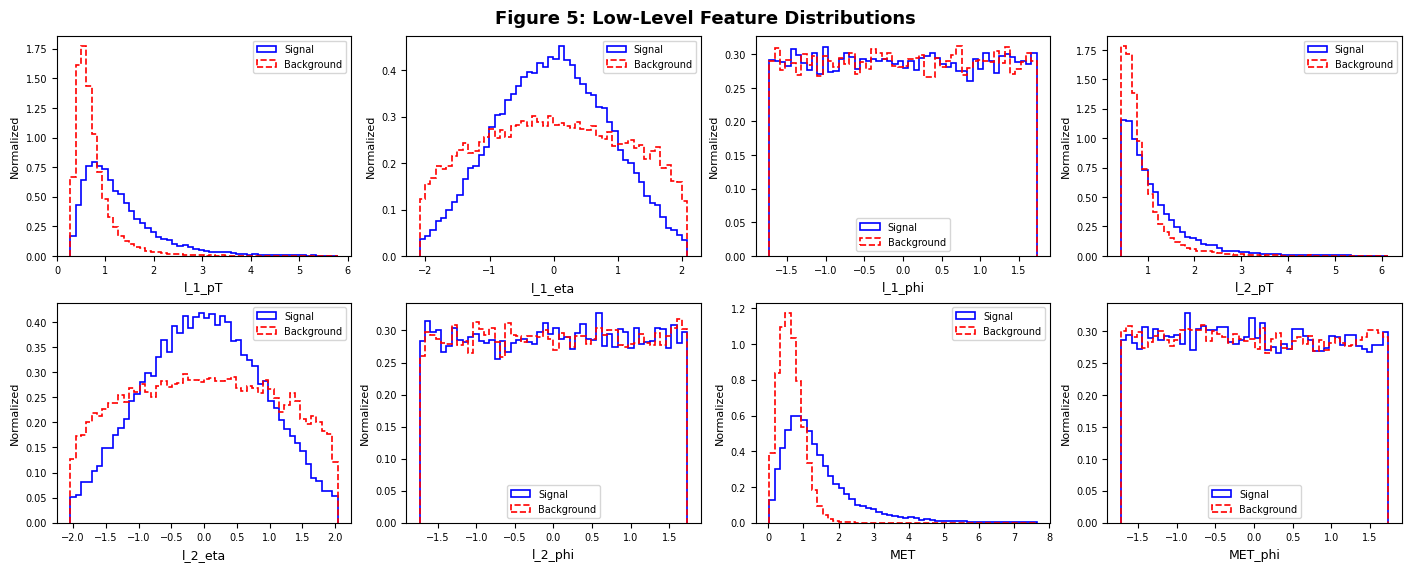

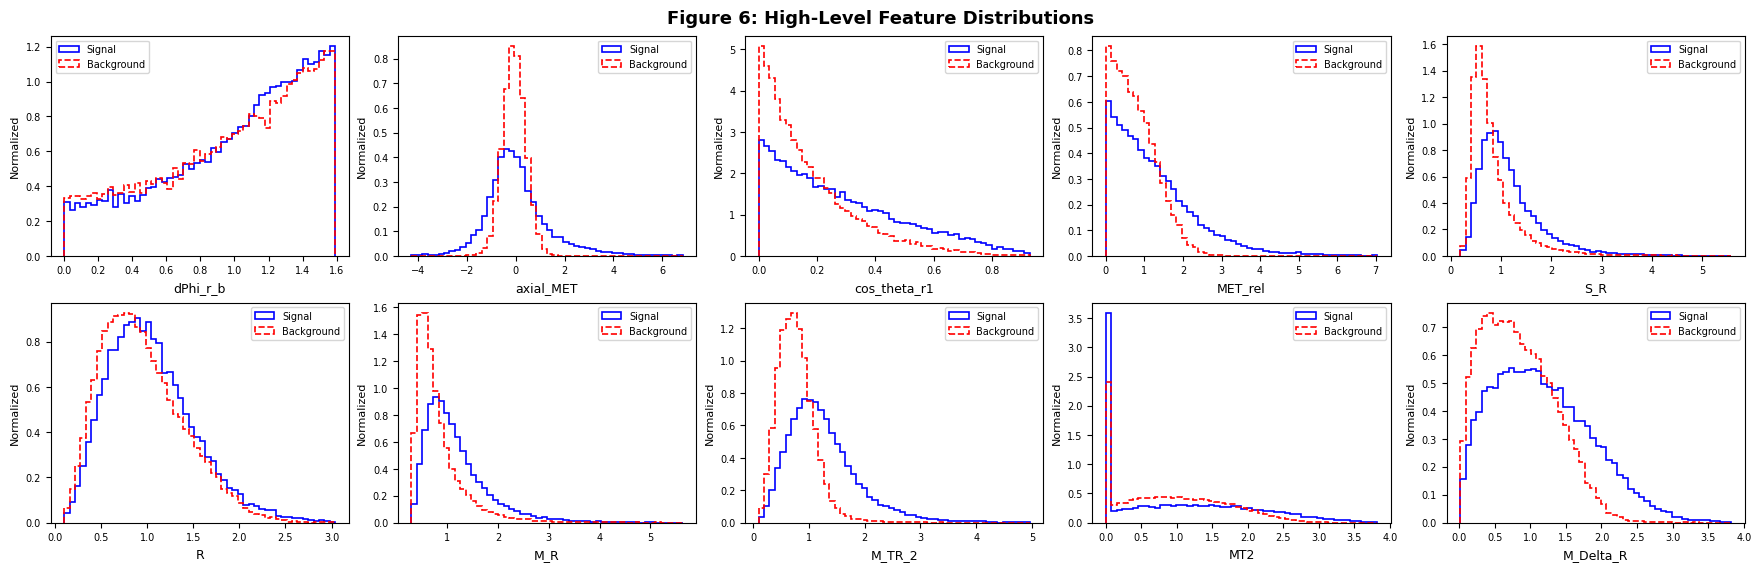

In [94]:
def plot_paper_figure(var_list, title, ncols=4):
    #Clalculating number of rows needed
    nrows = int(np.ceil(len(var_list) / ncols))
    #Creating grid of subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    #Loop through each axes
    for ax, var in zip(axes, var_list):
        bins = np.linspace(df[var].quantile(0.001), df[var].quantile(0.999), 51)
        ax.hist(df_sig[var], bins=bins, histtype='step', color='blue',
                label='Signal', density=True, linewidth=1.2)
        ax.hist(df_bkg[var], bins=bins, histtype='step', color='red',
                label='Background', density=True, linewidth=1.2, linestyle='--')
        ax.set_xlabel(var, fontsize=9)
        ax.set_ylabel('Normalized', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    for ax in axes[len(var_list):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()

#plot low level features
plot_paper_figure(RawNames,     "Figure 5: Low-Level Feature Distributions",  ncols=4)

#plot high level features
plot_paper_figure(FeatureNames, "Figure 6: High-Level Feature Distributions", ncols=5)

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [ ]:
#Use a subsample before entering the loop so that we dont have to loop over n-million times.

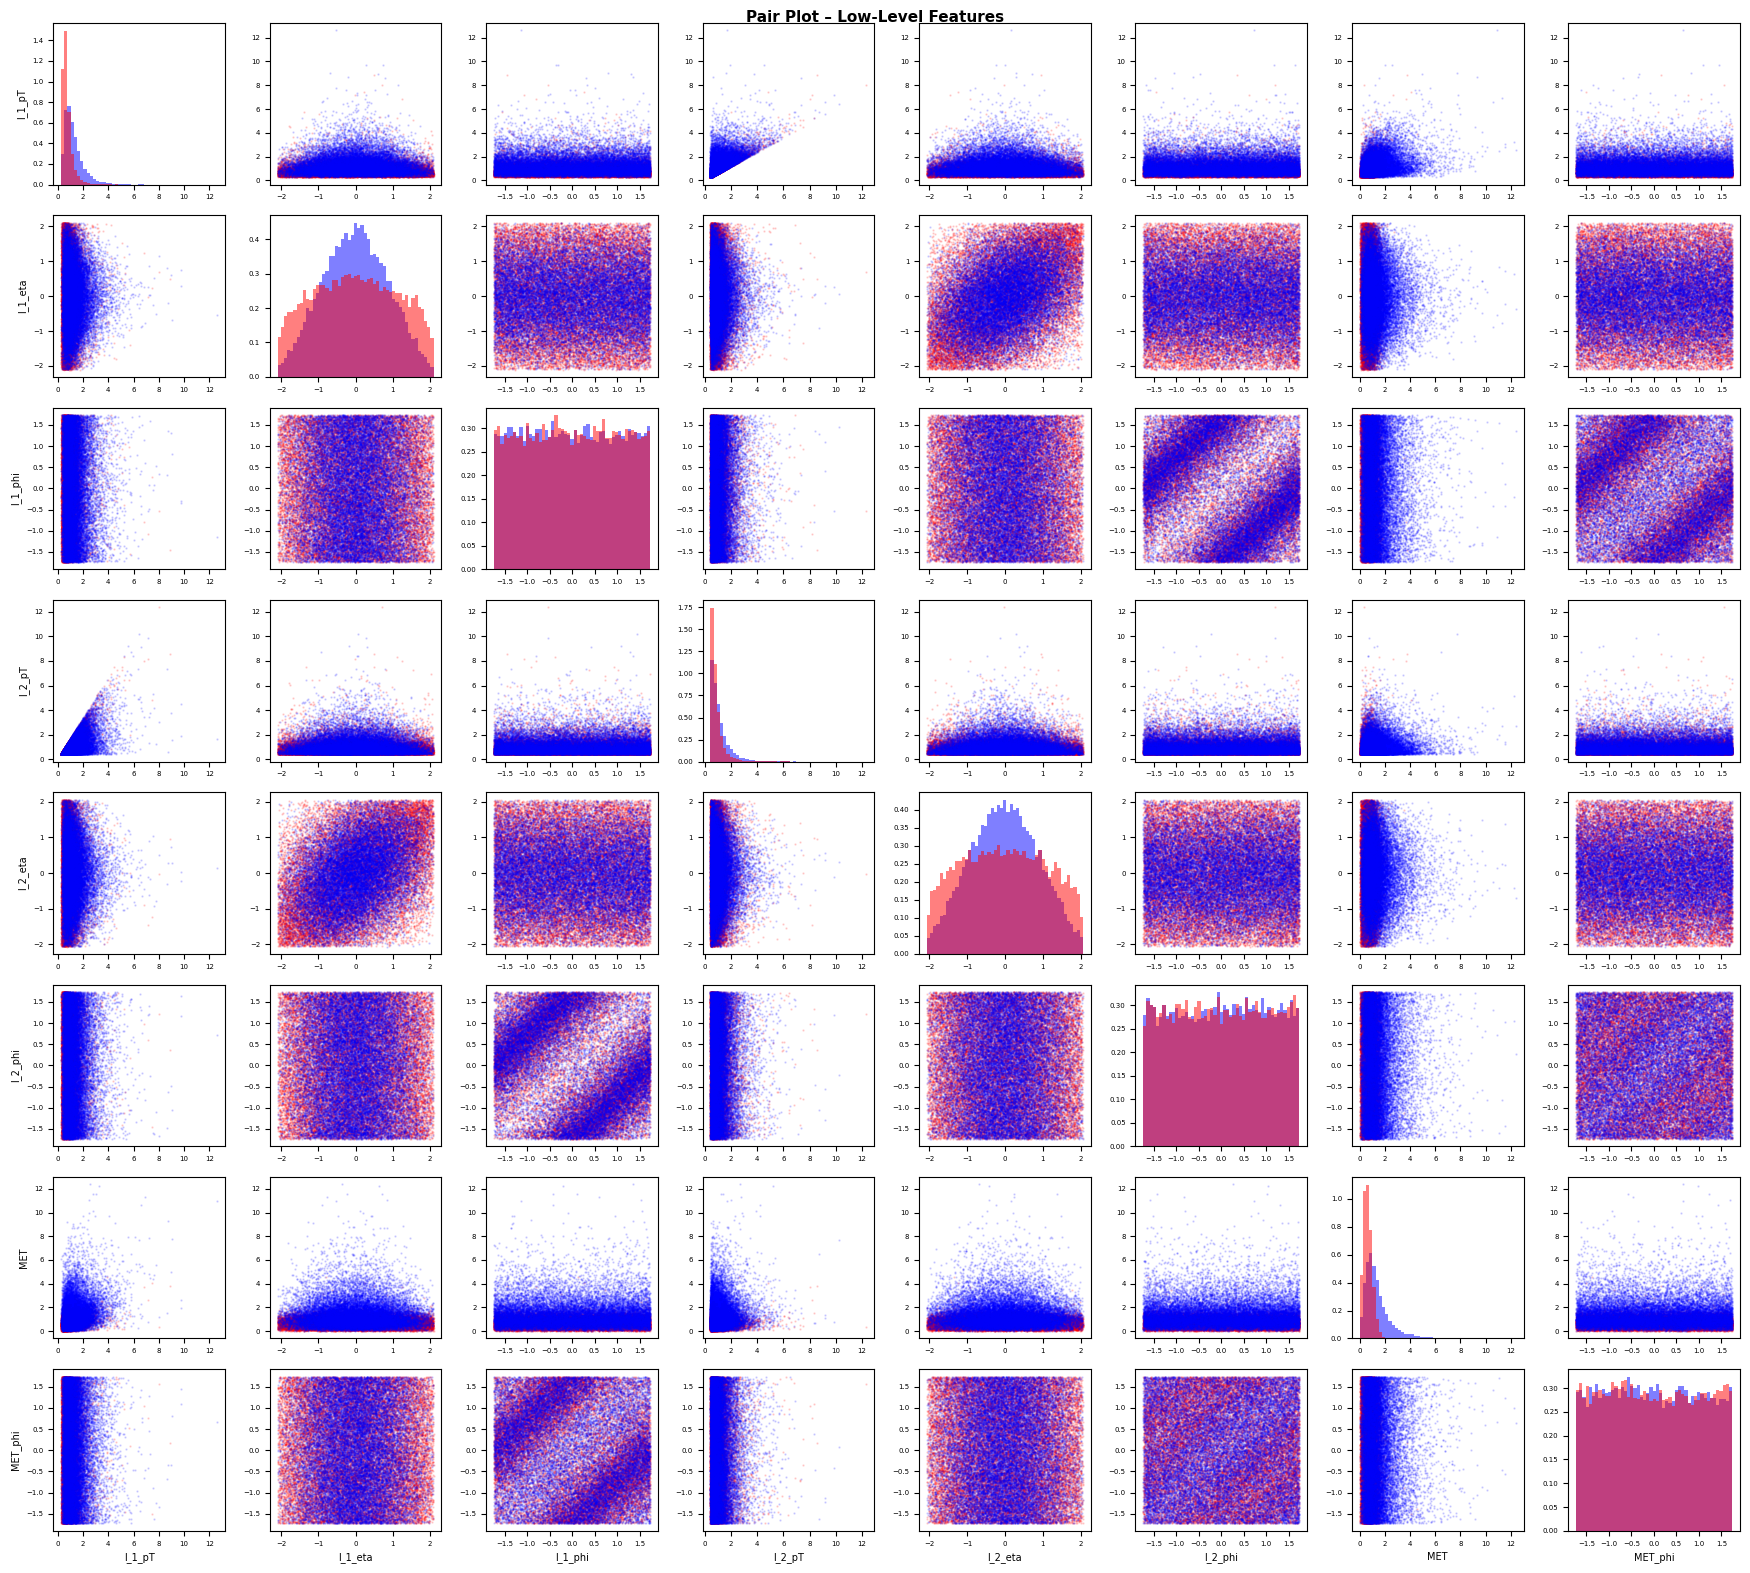

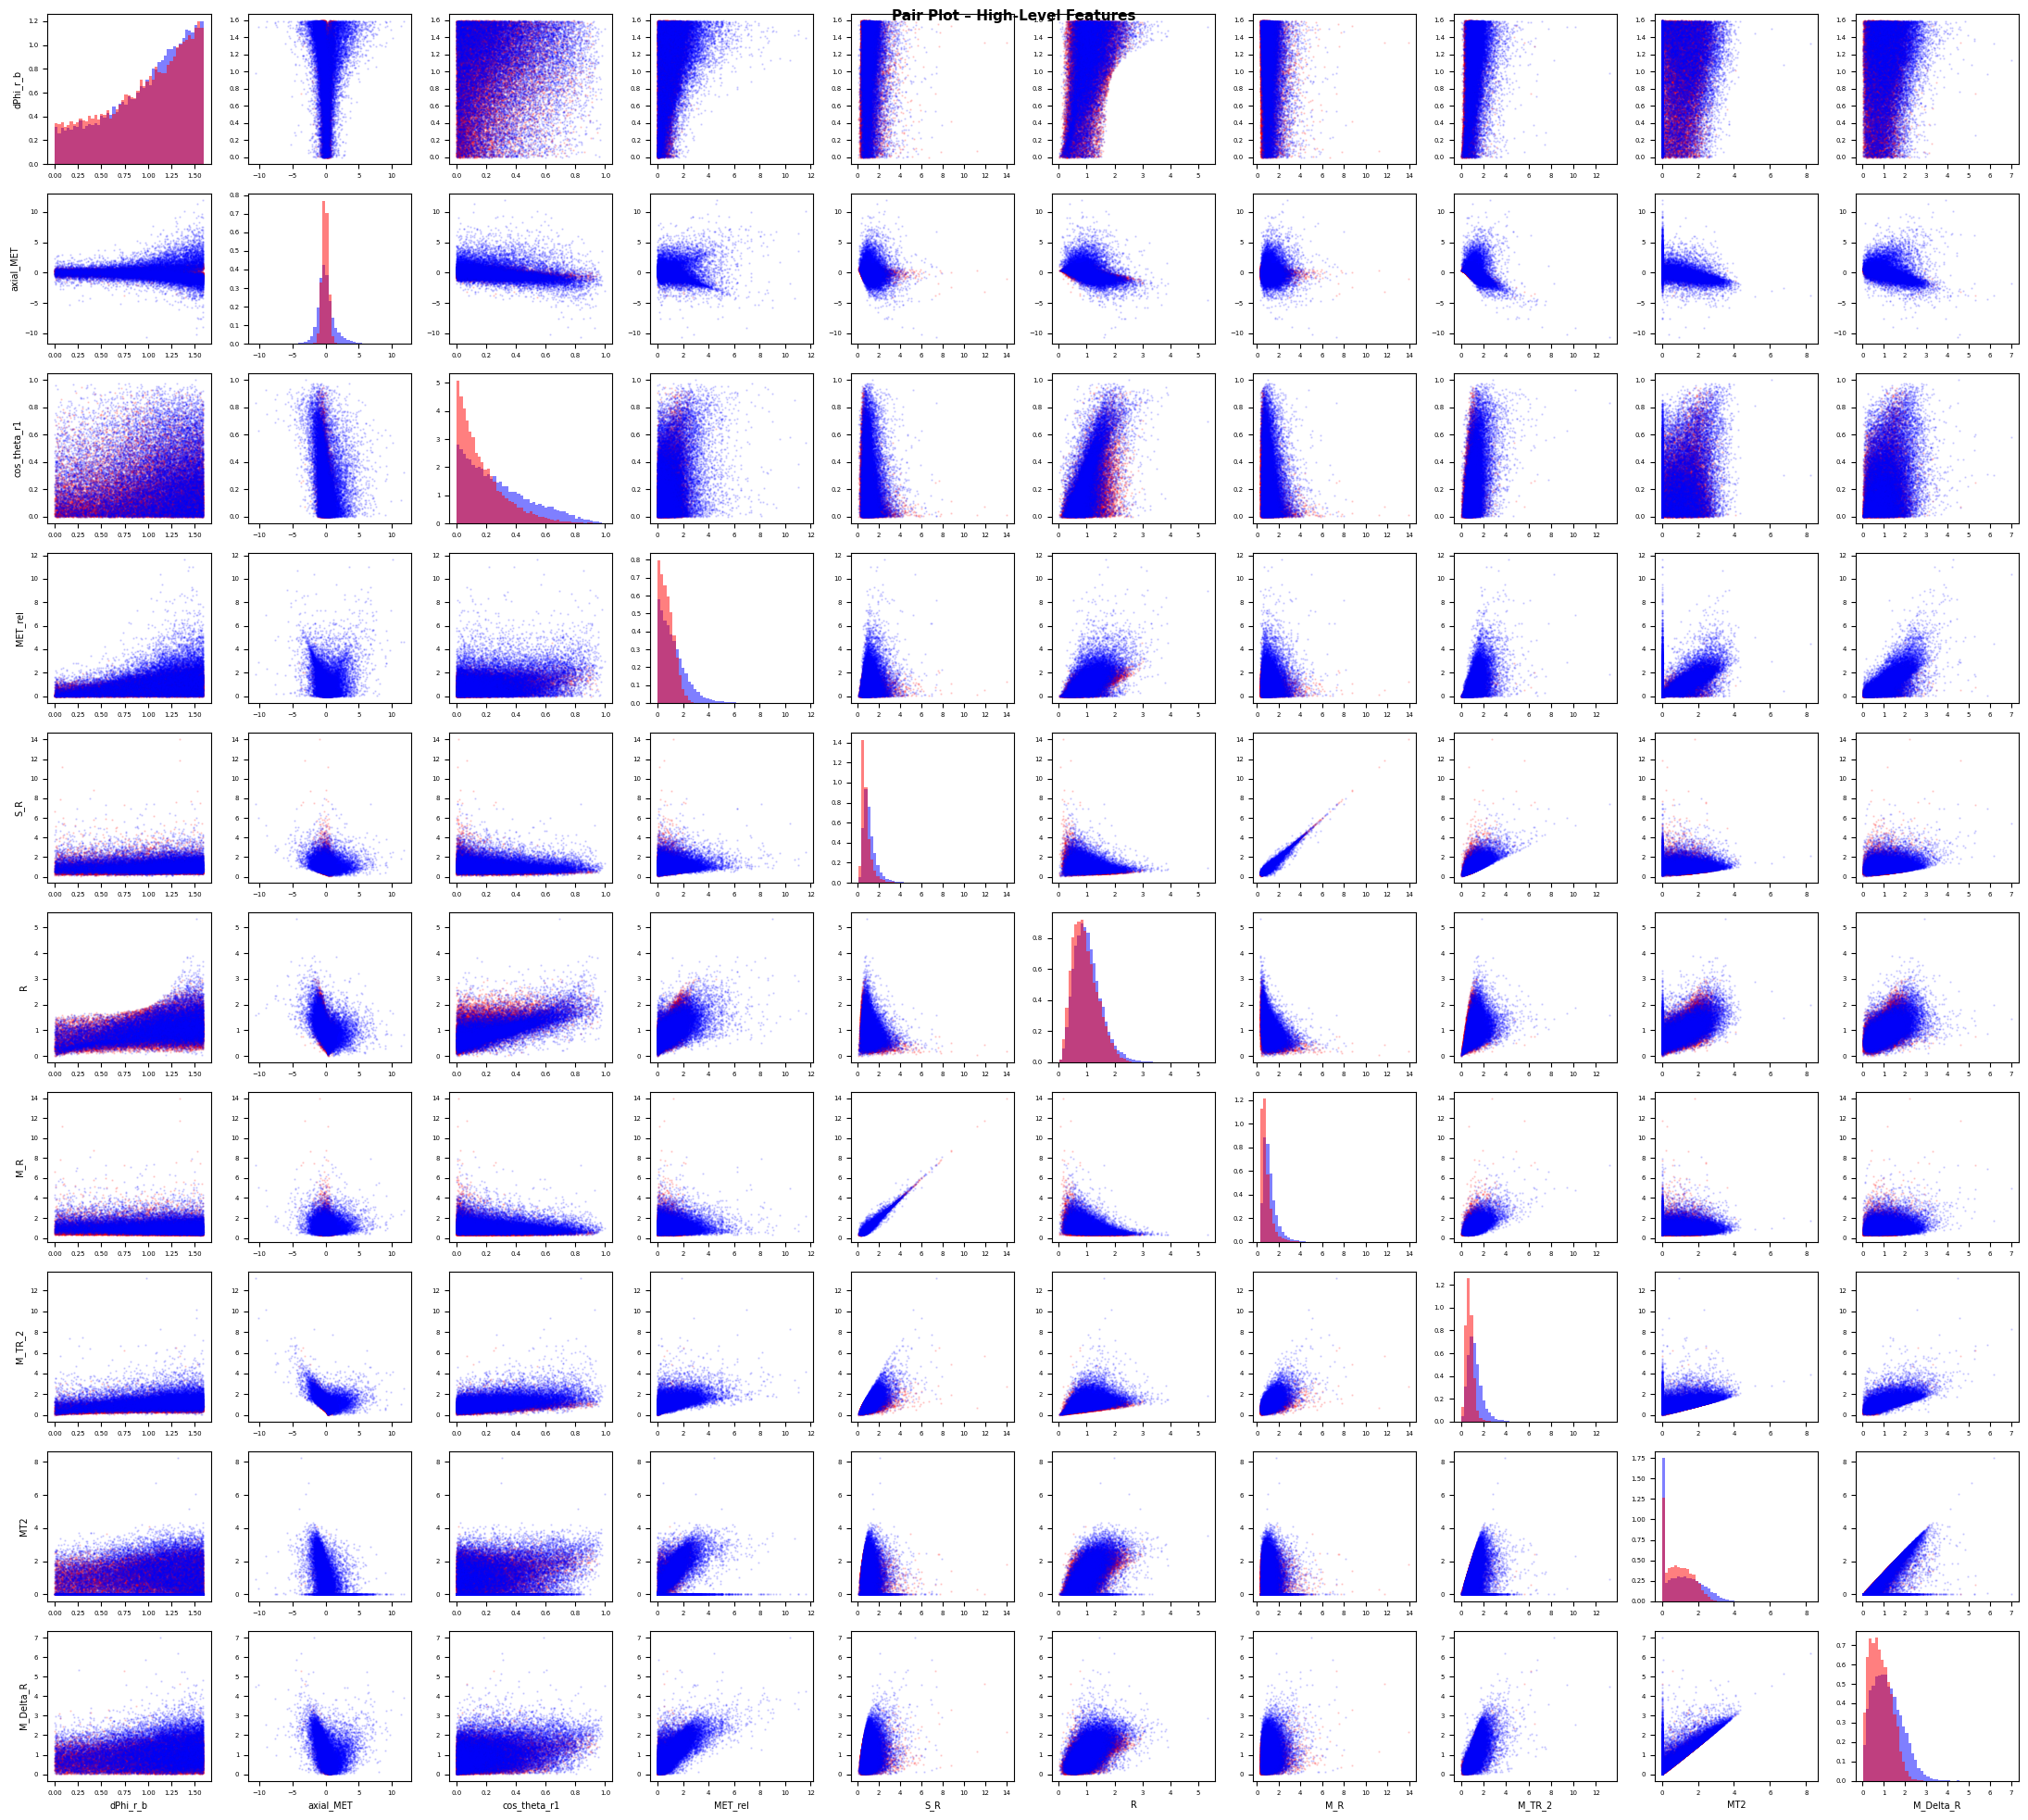

In [95]:
def pair_plot(df_s, df_b, var_list, title="Pair Plot", bins=50, sample_n=20000):
    # 4.1b: subsample once before the loop for speed
    rng = np.random.default_rng(42)
    s_idx = rng.choice(len(df_s), min(sample_n, len(df_s)), replace=False)
    b_idx = rng.choice(len(df_b), min(sample_n, len(df_b)), replace=False)
    sig = df_s[var_list].iloc[s_idx].to_numpy()
    bkg = df_b[var_list].iloc[b_idx].to_numpy()

    n = len(var_list)
    fig, axes = plt.subplots(n, n, figsize=(n * 2.2, n * 2.0))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                lo = min(sig[:, i].min(), bkg[:, i].min())
                hi = max(sig[:, i].max(), bkg[:, i].max())
                b = np.linspace(lo, hi, bins)
                ax.hist(sig[:, i], bins=b, color='blue', alpha=0.5, density=True)
                ax.hist(bkg[:, i], bins=b, color='red',  alpha=0.5, density=True)
            else:
                ax.scatter(bkg[:, j], bkg[:, i], s=0.5, c='red',  alpha=0.15, rasterized=True)
                ax.scatter(sig[:, j], sig[:, i], s=0.5, c='blue', alpha=0.15, rasterized=True)
            if i == n - 1: ax.set_xlabel(var_list[j], fontsize=7)
            if j == 0:     ax.set_ylabel(var_list[i], fontsize=7)
            ax.tick_params(labelsize=5)

    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

pair_plot(df_sig, df_bkg, RawNames,     title="Pair Plot – Low-Level Features")
pair_plot(df_sig, df_bkg, FeatureNames, title="Pair Plot – High-Level Features")

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [50]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [96]:
def compute_and_display_matrices(df_input, var_list, label=""):
    data = df_input[var_list].dropna().to_numpy().T   # shape (n_vars, n_samples)
    cov_mat  = np.cov(data)
    corr_mat = np.corrcoef(data)

    def matrix_to_table(mat, names, fmt):
        return [[name] + [format(mat[i, j], fmt) for j in range(len(names))]
                for i, name in enumerate(names)]

    headers = [""] + var_list

    print(f"\nCovariance Matrix – {label}")
    display(HTML(tabulate.tabulate(matrix_to_table(cov_mat, var_list, ".3g"),
                                   headers=headers, tablefmt='html')))

    print(f"\nCorrelation Matrix – {label}")
    display(HTML(tabulate.tabulate(matrix_to_table(corr_mat, var_list, ".3f"),
                                   headers=headers, tablefmt='html')))
    return cov_mat, corr_mat

cov_all,  corr_all  = compute_and_display_matrices(df, VarNames[1:], "All Observables")
cov_raw,  corr_raw  = compute_and_display_matrices(df, RawNames,     "Low-Level Features")
cov_feat, corr_feat = compute_and_display_matrices(df, FeatureNames, "High-Level Features")


Covariance Matrix – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.473,-0.00063,0.000177,0.305,0.00132,-0.00064,0.238,-0.00167,0.106,-0.0155,0.369,0.294,-0.0579,-0.0105,0.348,0.104,-0.0457,0.0232
l_1_eta,-0.00063,1.01,-0.0116,-0.000729,0.407,0.000756,-0.00788,-0.00486,-0.00381,-0.0104,-0.00119,-0.00148,-0.00023,0.00167,-0.000877,-0.00113,-0.00198,-0.00026
l_1_phi,0.000177,-0.0116,1.01,0.0044,-0.00877,-0.265,-0.00137,-0.188,-0.00112,-5.65e-05,0.00398,2.35e-06,-0.00253,0.000378,0.00389,-0.00129,0.00278,-0.000316
l_2_pT,0.305,-0.000729,0.0044,0.427,-8.16e-05,-0.00298,0.0831,-0.00379,0.0057,0.0481,0.328,0.166,-0.0981,-0.0664,0.325,0.0107,-0.00232,-0.0277
l_2_eta,0.00132,0.407,-0.00877,-8.16e-05,1.01,-0.00431,-0.00153,-0.00274,0.00393,-0.00981,0.0021,0.00185,0.000459,0.00696,0.00218,0.00339,-0.00144,0.000626
l_2_phi,-0.00064,0.000756,-0.265,-0.00298,-0.00431,1,0.00028,-0.0324,-0.00131,0.00289,-0.00339,-0.000445,0.000528,-0.000294,-0.00384,-0.00137,-0.00198,0.00078
MET,0.238,-0.00788,-0.00137,0.0831,-0.00153,0.00028,0.771,3.72e-05,0.548,0.153,0.151,0.371,0.184,0.157,0.171,0.315,0.145,0.0729
MET_phi,-0.00167,-0.00486,-0.188,-0.00379,-0.00274,-0.0324,3.72e-05,1,-0.00348,-0.00147,-0.00432,-0.000845,0.00326,0.00539,-0.00476,0.00067,-0.00171,0.00143
MET_rel,0.106,-0.00381,-0.00112,0.0057,0.00393,-0.00131,0.548,-0.00348,0.782,-0.114,0.0516,0.305,0.243,0.407,0.0891,0.41,0.146,0.0545
axial_MET,-0.0155,-0.0104,-5.65e-05,0.0481,-0.00981,0.00289,0.153,-0.00147,-0.114,1.02,0.012,-0.196,-0.184,-0.459,-0.049,-0.234,-0.0274,-0.0546



Correlation Matrix – All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.68,0.002,-0.001,0.394,-0.002,0.174,-0.022,0.851,0.728,-0.18,-0.018,0.81,0.243,-0.152,0.171
l_1_eta,-0.001,1,-0.012,-0.001,0.404,0.001,-0.009,-0.005,-0.004,-0.01,-0.002,-0.003,-0,0.002,-0.001,-0.002,-0.005,-0.001
l_1_phi,0,-0.012,1,0.007,-0.009,-0.264,-0.002,-0.187,-0.001,-0,0.006,0,-0.005,0,0.006,-0.002,0.006,-0.002
l_2_pT,0.68,-0.001,0.007,1,-0,-0.005,0.145,-0.006,0.01,0.073,0.796,0.432,-0.321,-0.119,0.798,0.026,-0.008,-0.215
l_2_eta,0.002,0.404,-0.009,-0,1,-0.004,-0.002,-0.003,0.004,-0.01,0.003,0.003,0.001,0.008,0.003,0.005,-0.003,0.003
l_2_phi,-0.001,0.001,-0.264,-0.005,-0.004,1,0,-0.032,-0.001,0.003,-0.005,-0.001,0.001,-0,-0.006,-0.002,-0.005,0.004
MET,0.394,-0.009,-0.002,0.145,-0.002,0,1,0,0.706,0.173,0.273,0.719,0.447,0.208,0.313,0.577,0.38,0.421
MET_phi,-0.002,-0.005,-0.187,-0.006,-0.003,-0.032,0,1,-0.004,-0.001,-0.007,-0.001,0.007,0.006,-0.008,0.001,-0.004,0.007
MET_rel,0.174,-0.004,-0.001,0.01,0.004,-0.001,0.706,-0.004,1,-0.127,0.093,0.586,0.586,0.536,0.161,0.745,0.38,0.313
axial_MET,-0.022,-0.01,-0,0.073,-0.01,0.003,0.173,-0.001,-0.127,1,0.019,-0.33,-0.388,-0.53,-0.078,-0.371,-0.062,-0.274



Covariance Matrix – Low-Level Features


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.68,0.002,-0.001,0.394,-0.002
l_1_eta,-0.001,1,-0.012,-0.001,0.404,0.001,-0.009,-0.005
l_1_phi,0,-0.012,1,0.007,-0.009,-0.264,-0.002,-0.187
l_2_pT,0.68,-0.001,0.007,1,-0,-0.005,0.145,-0.006
l_2_eta,0.002,0.404,-0.009,-0,1,-0.004,-0.002,-0.003
l_2_phi,-0.001,0.001,-0.264,-0.005,-0.004,1,0,-0.032
MET,0.394,-0.009,-0.002,0.145,-0.002,0,1,0
MET_phi,-0.002,-0.005,-0.187,-0.006,-0.003,-0.032,0,1



Covariance Matrix – High-Level Features


,dPhi_r_b,axial_MET,cos_theta_r1,MET_rel,S_R,R,M_R,M_TR_2,MT2,M_Delta_R
dPhi_r_b,0.19,-0.0274,0.00896,0.146,-0.00121,0.086,-0.027,0.0592,0.0215,0.0416
axial_MET,-0.0274,1.02,-0.0546,-0.114,-0.049,-0.184,0.012,-0.196,-0.459,-0.234
cos_theta_r1,0.00896,-0.0546,0.0389,0.0545,-0.00999,0.0577,-0.0139,0.0521,0.044,0.0385
MET_rel,0.146,-0.114,0.0545,0.782,0.0891,0.243,0.0516,0.305,0.407,0.41
S_R,-0.00121,-0.049,-0.00999,0.0891,0.389,-0.0821,0.386,0.235,-0.0084,0.102
R,0.086,-0.184,0.0577,0.243,-0.0821,0.219,-0.112,0.104,0.231,0.162
M_R,-0.027,0.012,-0.0139,0.0516,0.386,-0.112,0.398,0.216,-0.0342,0.0805
M_TR_2,0.0592,-0.196,0.0521,0.305,0.235,0.104,0.216,0.346,0.191,0.245
MT2,0.0215,-0.459,0.044,0.407,-0.0084,0.231,-0.0342,0.191,0.736,0.432
M_Delta_R,0.0416,-0.234,0.0385,0.41,0.102,0.162,0.0805,0.245,0.432,0.388



Correlation Matrix – High-Level Features


,dPhi_r_b,axial_MET,cos_theta_r1,MET_rel,S_R,R,M_R,M_TR_2,MT2,M_Delta_R
dPhi_r_b,1,-0.062,0.104,0.38,-0.004,0.42,-0.098,0.231,0.057,0.153
axial_MET,-0.062,1,-0.274,-0.127,-0.078,-0.388,0.019,-0.33,-0.53,-0.371
cos_theta_r1,0.104,-0.274,1,0.313,-0.081,0.624,-0.111,0.45,0.26,0.313
MET_rel,0.38,-0.127,0.313,1,0.161,0.586,0.093,0.586,0.536,0.745
S_R,-0.004,-0.078,-0.081,0.161,1,-0.281,0.981,0.64,-0.016,0.262
R,0.42,-0.388,0.624,0.586,-0.281,1,-0.377,0.378,0.575,0.556
M_R,-0.098,0.019,-0.111,0.093,0.981,-0.377,1,0.582,-0.063,0.205
M_TR_2,0.231,-0.33,0.45,0.586,0.64,0.378,0.582,1,0.378,0.668
MT2,0.057,-0.53,0.26,0.536,-0.016,0.575,-0.063,0.378,1,0.81
M_Delta_R,0.153,-0.371,0.313,0.745,0.262,0.556,0.205,0.668,0.81,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [98]:
#5.1

def determine_cut_strategy(df_s, df_b, var):
    ms, mb = df_s[var].mean(), df_b[var].mean()
    ss, sb = df_s[var].std(),  df_b[var].std()
    mu = (ms + mb) / 2
    if abs(ms - mb) > 0.1 * (ss + sb) / 2:
        return ("x > xc" if ms > mb else "x < xc"), mu
    else:
        return ("|x-mu| < xc" if ss < sb else "|x-mu| > xc"), mu

strategies = {}
for var in VarNames[1:]:
    strategies[var] = determine_cut_strategy(df_sig, df_bkg, var)
    print(f"{var:<20}  {strategies[var][0]:<18}  mu={strategies[var][1]:.3f}")

l_1_pT                x > xc              mu=1.024
l_1_eta               |x-mu| < xc         mu=-0.005
l_1_phi               |x-mu| > xc         mu=-0.001
l_2_pT                x > xc              mu=1.010
l_2_eta               |x-mu| < xc         mu=-0.007
l_2_phi               |x-mu| > xc         mu=0.006
MET                   x > xc              mu=1.032
MET_phi               |x-mu| < xc         mu=-0.006
MET_rel               x > xc              mu=1.020
axial_MET             x > xc              mu=0.008
M_R                   x > xc              mu=1.016
M_TR_2                x > xc              mu=1.021
R                     x > xc              mu=1.002
MT2                   x > xc              mu=1.007
S_R                   x > xc              mu=1.013
M_Delta_R             x > xc              mu=1.015
dPhi_r_b              |x-mu| < xc         mu=0.998
cos_theta_r1          x > xc              mu=0.229


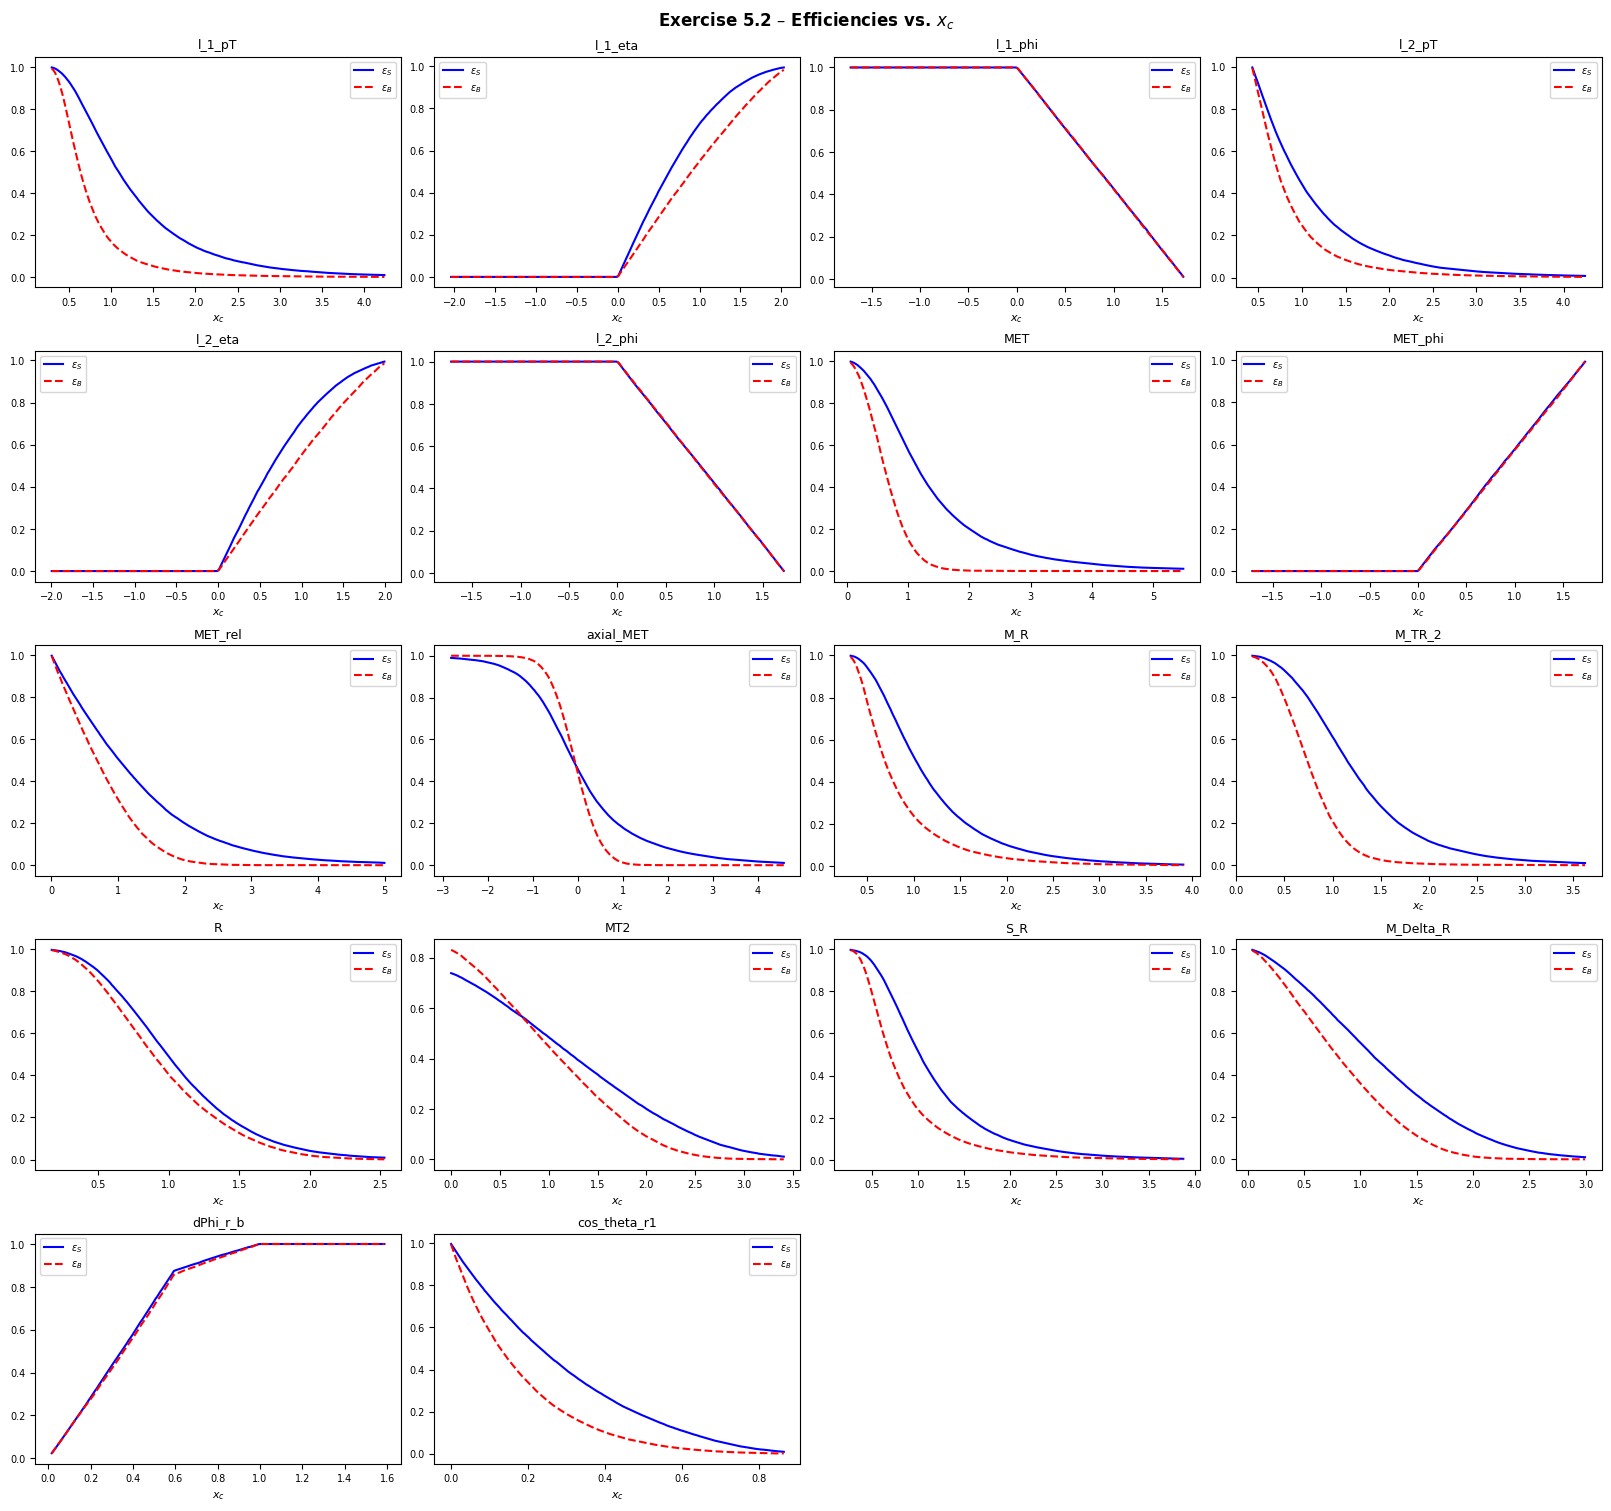

In [100]:
#5.2
def compute_efficiencies(df_s, df_b, var, strategy, mu, n_cuts=200):
    lo, hi = df[var].quantile(0.005), df[var].quantile(0.995)
    xc_vals = np.linspace(lo, hi, n_cuts)
    sig_arr, bkg_arr = df_s[var].to_numpy(), df_b[var].to_numpy()
    N_s, N_b = len(sig_arr), len(bkg_arr)
    TPR, FPR = np.empty(n_cuts), np.empty(n_cuts)

    for k, xc in enumerate(xc_vals):
        #Apply selection strategy
        if strategy == "x > xc":
            ns, nb = np.sum(sig_arr > xc), np.sum(bkg_arr > xc)
        elif strategy == "x < xc":
            ns, nb = np.sum(sig_arr < xc), np.sum(bkg_arr < xc)
        elif strategy == "|x-mu| < xc":
            ns, nb = np.sum(np.abs(sig_arr-mu) < xc), np.sum(np.abs(bkg_arr-mu) < xc)
        else:
            ns, nb = np.sum(np.abs(sig_arr-mu) > xc), np.sum(np.abs(bkg_arr-mu) > xc)

        #Computing efficiencies
        TPR[k], FPR[k] = ns / N_s, nb / N_b

    return xc_vals, TPR, FPR

# Pre-compute for all variables
eff_cache = {var: compute_efficiencies(df_sig, df_bkg, var, *strategies[var])
             for var in VarNames[1:]}

# Plot
ncols = 4
nrows = int(np.ceil((len(VarNames)-1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), constrained_layout=True)
axes = np.array(axes).flatten()

for ax, var in zip(axes, VarNames[1:]):
    xc_vals, TPR, FPR = eff_cache[var]
    ax.plot(xc_vals, TPR, 'b-',  label=r'$\epsilon_S$')
    ax.plot(xc_vals, FPR, 'r--', label=r'$\epsilon_B$')
    ax.set_title(var, fontsize=9); ax.set_xlabel('$x_c$', fontsize=8)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)

#Hide unused sub-plots
for ax in axes[len(VarNames)-1:]: ax.set_visible(False)

fig.suptitle("Exercise 5.2 – Efficiencies vs. $x_c$", fontsize=12, fontweight='bold')
plt.show()

/var/folders/35/fl777nb577g3_yjydgxfgptr0000gn/T/ipykernel_52254/2495791662.py:12: RuntimeWarning: invalid value encountered in divide
  return np.where(denom > 0, Np_s / denom, 0.0)


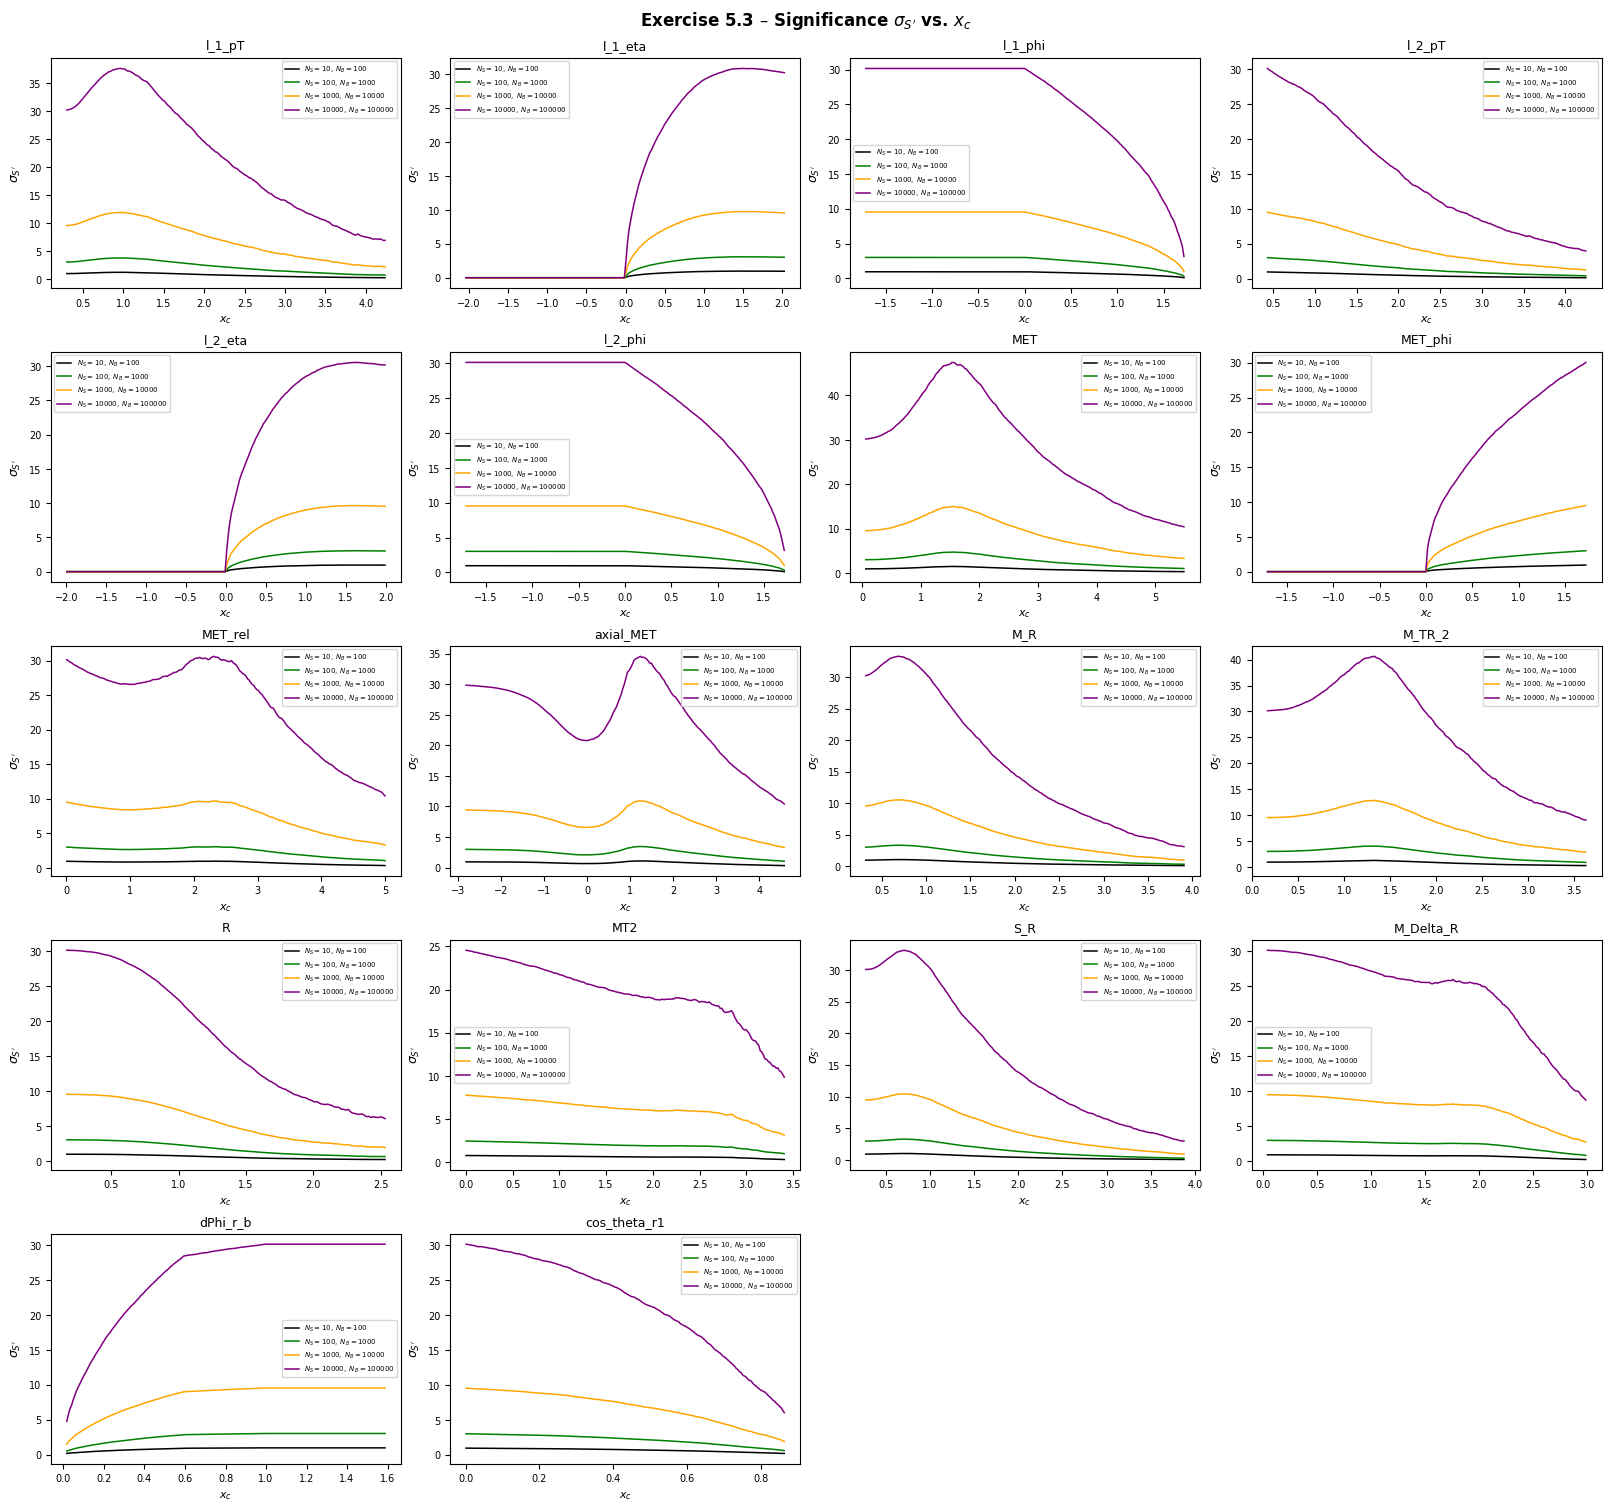

In [103]:
#5.3
scenarios = [
    (10,    100,    r"$N_S=10,\; N_B=100$"),
    (100,   1000,   r"$N_S=100,\; N_B=1000$"),
    (1000,  10000,  r"$N_S=1000,\; N_B=10000$"),
    (10000, 100000, r"$N_S=10000,\; N_B=100000$"),
]

def significance(eps_s, eps_b, N_s, N_b):
    Np_s, Np_b = eps_s * N_s, eps_b * N_b
    denom = np.sqrt(Np_s + Np_b)
    return np.where(denom > 0, Np_s / denom, 0.0)

colors = ['black', 'green', 'orange', 'purple']
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3), constrained_layout=True)
axes = np.array(axes).flatten()

for ax, var in zip(axes, VarNames[1:]):
    xc_vals, TPR, FPR = eff_cache[var]
    for (N_s, N_b, label), color in zip(scenarios, colors):
        ax.plot(xc_vals, significance(TPR, FPR, N_s, N_b),
                color=color, label=label, linewidth=1.1)
    ax.set_title(var, fontsize=9); ax.set_xlabel('$x_c$', fontsize=8)
    ax.set_ylabel(r"$\sigma_{S'}$", fontsize=9)
    ax.legend(fontsize=5); ax.tick_params(labelsize=7)

for ax in axes[len(VarNames)-1:]: ax.set_visible(False)
fig.suptitle(r"Exercise 5.3 – Significance $\sigma_{S'}$ vs. $x_c$",
             fontsize=12, fontweight='bold')
plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [104]:
#6.1

# From significance plots, top separating observables and their optimal xc
# Strategy and xc chosen by finding argmax of significance in scenario 4 (most stats)

selected_vars = ["M_R", "M_TR_2", "S_R", "R", "MT2"]

# Read optimal xc from eff_cache for each variable (argmax significance, scenario 4)
N_s4, N_b4 = 10000, 100000
chosen_cuts = {}
for var in selected_vars:
    xc_vals, TPR, FPR = eff_cache[var]
    strat, mu = strategies[var]
    sigs = significance(TPR, FPR, N_s4, N_b4)
    best_xc = xc_vals[np.argmax(sigs)]
    chosen_cuts[var] = (strat, mu, best_xc)
    print(f"{var:<15}  strategy: {strat:<18}  xc={best_xc:.4f}  max_sig={sigs.max():.3f}")

M_R              strategy: x > xc              xc=0.6800  max_sig=33.276
M_TR_2           strategy: x > xc              xc=1.3308  max_sig=40.628
S_R              strategy: x > xc              xc=0.7060  max_sig=33.127
R                strategy: x > xc              xc=0.1684  max_sig=30.111
MT2              strategy: x > xc              xc=0.0000  max_sig=24.560


In [128]:
#6.2
def apply_cut(arr, strategy, mu, xc):
    """Return boolean mask of events passing the cut."""
    if strategy == "x > xc":
        return arr > xc
    elif strategy == "x < xc":
        return arr < xc
    elif strategy == "|x-mu| < xc":
        return np.abs(arr - mu) < xc
    else:  # |x-mu| > xc
        return np.abs(arr - mu) > xc


def cut_flow_table(df_s, df_b, cut_list, N_s, N_b, label=""):

    #cut_list : list of (var, strategy, mu, xc)

    sig_mask = np.ones(len(df_s), dtype=bool)
    bkg_mask = np.ones(len(df_b), dtype=bool)

    rows = []
    # Row 0: no cuts
    rows.append(["(no cut)", 1.0, 1.0, N_s, N_b,
                 significance(1.0, 1.0, N_s, N_b)])

    for var, strat, mu, xc in cut_list:
        sig_mask &= apply_cut(df_s[var].to_numpy(), strat, mu, xc)
        bkg_mask &= apply_cut(df_b[var].to_numpy(), strat, mu, xc)

        eps_s = sig_mask.sum() / len(df_s)
        eps_b = bkg_mask.sum() / len(df_b)
        Np_s  = eps_s * N_s
        Np_b  = eps_b * N_b
        sig   = significance(eps_s, eps_b, N_s, N_b)

        cut_label = f"{var} ({strat}, xc={xc:.3f})"
        rows.append([cut_label,
                     f"{eps_s:.4f}", f"{eps_b:.6f}",
                     f"{Np_s:.2f}", f"{Np_b:.2f}", f"{sig:.3f}"])

    headers = ["Cut", "ε_S", "ε_B", "N'_S", "N'_B", "σ_S'"]
    print(f"\n{'='*70}")
    print(f"Cut Flow – {label}  (N_S={N_s}, N_B={N_b})")
    print('='*70)
    display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))


# Build cut list from chosen cuts
cut_list = [(var, *chosen_cuts[var]) for var in selected_vars]

for N_s, N_b, label in scenarios:
    cut_flow_table(df_sig, df_bkg, cut_list, N_s, N_b, label)


Cut Flow – $N_S=10,\; N_B=100$  (N_S=10, N_B=100)


Cut,ε_S,ε_B,N'_S,N'_B,σ_S'
(no cut),1,1,10,100,0.953463
"M_R (x > xc, xc=0.680)",0.8085,0.509484,8.09,50.95,1.052
"M_TR_2 (x > xc, xc=1.331)",0.3587,0.046347,3.59,4.63,1.251
"S_R (x > xc, xc=0.706)",0.3584,0.046347,3.58,4.63,1.25
"R (x > xc, xc=0.168)",0.3584,0.04631,3.58,4.63,1.251
"MT2 (x > xc, xc=0.000)",0.2731,0.041901,2.73,4.19,1.038



Cut Flow – $N_S=100,\; N_B=1000$  (N_S=100, N_B=1000)


Cut,ε_S,ε_B,N'_S,N'_B,σ_S'
(no cut),1,1,100,1000,3.01511
"M_R (x > xc, xc=0.680)",0.8085,0.509484,80.85,509.48,3.328
"M_TR_2 (x > xc, xc=1.331)",0.3587,0.046347,35.87,46.35,3.956
"S_R (x > xc, xc=0.706)",0.3584,0.046347,35.84,46.35,3.954
"R (x > xc, xc=0.168)",0.3584,0.04631,35.84,46.31,3.955
"MT2 (x > xc, xc=0.000)",0.2731,0.041901,27.31,41.9,3.283



Cut Flow – $N_S=1000,\; N_B=10000$  (N_S=1000, N_B=10000)


Cut,ε_S,ε_B,N'_S,N'_B,σ_S'
(no cut),1,1,1000,10000,9.53463
"M_R (x > xc, xc=0.680)",0.8085,0.509484,808.5,5094.84,10.523
"M_TR_2 (x > xc, xc=1.331)",0.3587,0.046347,358.7,463.47,12.51
"S_R (x > xc, xc=0.706)",0.3584,0.046347,358.44,463.47,12.503
"R (x > xc, xc=0.168)",0.3584,0.04631,358.44,463.1,12.506
"MT2 (x > xc, xc=0.000)",0.2731,0.041901,273.12,419.01,10.382



Cut Flow – $N_S=10000,\; N_B=100000$  (N_S=10000, N_B=100000)


Cut,ε_S,ε_B,N'_S,N'_B,σ_S'
(no cut),1,1,10000,100000,30.1511
"M_R (x > xc, xc=0.680)",0.8085,0.509484,8085.01,50948.4,33.276
"M_TR_2 (x > xc, xc=1.331)",0.3587,0.046347,3587.01,4634.71,39.56
"S_R (x > xc, xc=0.706)",0.3584,0.046347,3584.41,4634.71,39.537
"R (x > xc, xc=0.168)",0.3584,0.04631,3584.41,4631,39.546
"MT2 (x > xc, xc=0.000)",0.2731,0.041901,2731.22,4190.13,32.829


In [129]:
#6.3

# Print the correlation matrix for selected variables (signal events)
cov_sel, corr_sel = compute_and_display_matrices(
    df_sig, selected_vars, "Signal – Selected Variables")

# Also for background
cov_sel_b, corr_sel_b = compute_and_display_matrices(
    df_bkg, selected_vars, "Background – Selected Variables")


Covariance Matrix – Signal – Selected Variables


,M_R,M_TR_2,S_R,R,MT2
M_R,0.445,0.273,0.423,-0.123,-0.0715
M_TR_2,0.273,0.48,0.31,0.131,0.205
S_R,0.423,0.31,0.43,-0.0734,-0.0287
R,-0.123,0.131,-0.0734,0.237,0.249
MT2,-0.0715,0.205,-0.0287,0.249,0.959



Correlation Matrix – Signal – Selected Variables


,M_R,M_TR_2,S_R,R,MT2
M_R,1,0.59,0.967,-0.379,-0.11
M_TR_2,0.59,1,0.681,0.387,0.302
S_R,0.967,0.681,1,-0.23,-0.045
R,-0.379,0.387,-0.23,1,0.522
MT2,-0.11,0.302,-0.045,0.522,1



Covariance Matrix – Background – Selected Variables


,M_R,M_TR_2,S_R,R,MT2
M_R,0.305,0.0883,0.303,-0.118,-0.0244
M_TR_2,0.0883,0.117,0.0958,0.0581,0.147
S_R,0.303,0.0958,0.305,-0.105,-0.0121
R,-0.118,0.0581,-0.105,0.199,0.21
MT2,-0.0244,0.147,-0.0121,0.21,0.537



Correlation Matrix – Background – Selected Variables


,M_R,M_TR_2,S_R,R,MT2
M_R,1,0.468,0.995,-0.478,-0.06
M_TR_2,0.468,1,0.508,0.38,0.586
S_R,0.995,0.508,1,-0.425,-0.03
R,-0.478,0.38,-0.425,1,0.64
MT2,-0.06,0.586,-0.03,0.64,1


M_R and S_R are correlated at 0.967(signal) and 0.995(background). In background they are essentially the same variable. Independent optimization assumption breaks down here.

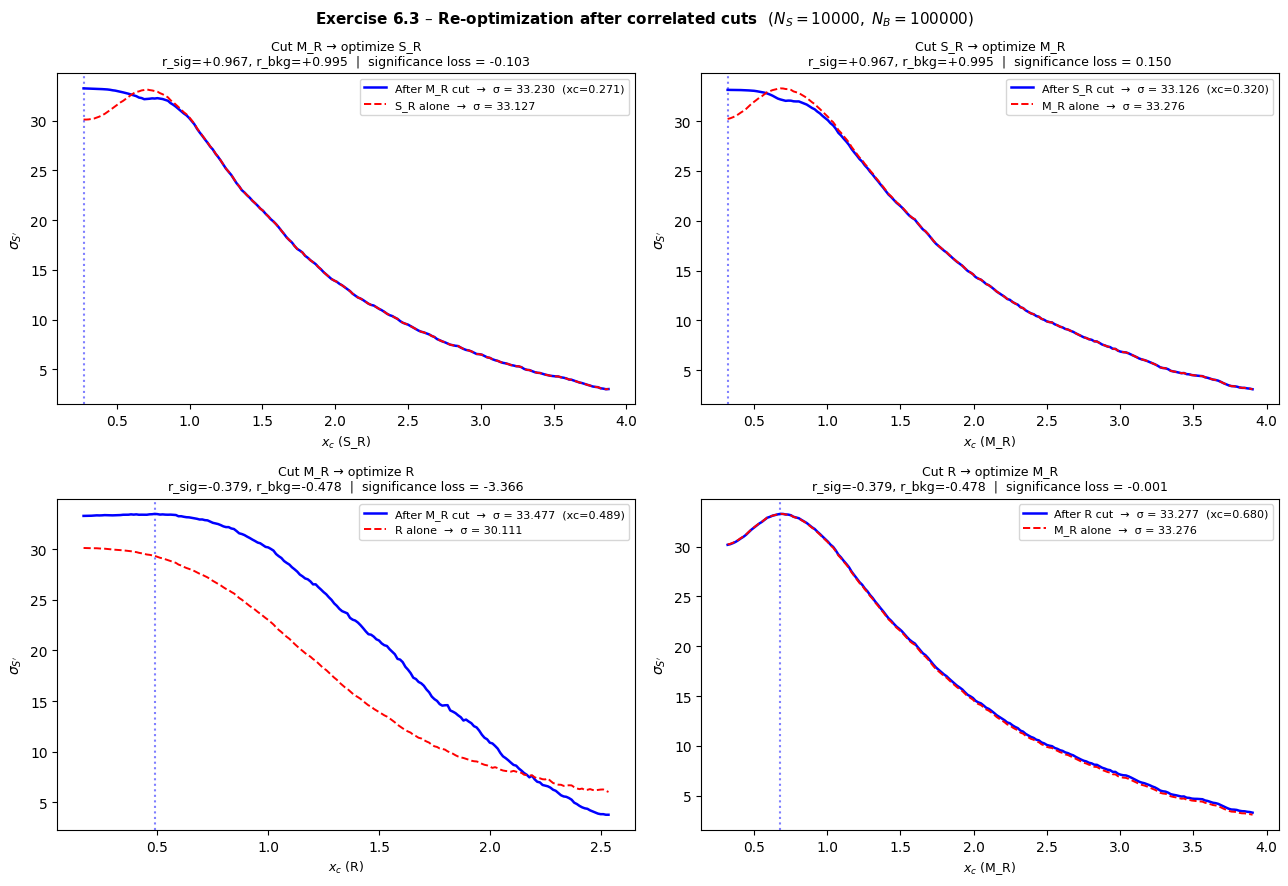

In [130]:
# RE-optimization Code

def apply_cut(arr, strategy, mu, xc):
    if strategy == "x > xc":
        return arr > xc
    elif strategy == "x < xc":
        return arr < xc
    elif strategy == "|x-mu| < xc":
        return np.abs(arr - mu) < xc
    else:  # |x-mu| > xc
        return np.abs(arr - mu) > xc


def reoptimize_second_cut(df_s, df_b, var_first, var_second, N_s, N_b, n_cuts=200):

    #Apply the optimal cut on var_first, then scan xc for var_second
    #on the surviving events. Efficiencies are kept relative to the
    #original (uncut) sample so significance is comparable.

    strat1, mu1, xc1 = chosen_cuts[var_first]
    strat2, mu2, _   = chosen_cuts[var_second]

    # Apply first cut
    mask_s = apply_cut(df_s[var_first].to_numpy(), strat1, mu1, xc1)
    mask_b = apply_cut(df_b[var_first].to_numpy(), strat1, mu1, xc1)

    df_s_cut = df_s[mask_s]
    df_b_cut = df_b[mask_b]

    # Efficiency of first cut relative to original sample
    eps_s1 = mask_s.sum() / len(df_s)
    eps_b1 = mask_b.sum() / len(df_b)

    # Scan xc for second variable on surviving events
    lo = df[var_second].quantile(0.005)
    hi = df[var_second].quantile(0.995)
    xc_vals = np.linspace(lo, hi, n_cuts)

    sig_arr = df_s_cut[var_second].to_numpy()
    bkg_arr = df_b_cut[var_second].to_numpy()

    TPR2 = np.empty(n_cuts)
    FPR2 = np.empty(n_cuts)

    for k, xc in enumerate(xc_vals):
        ns = apply_cut(sig_arr, strat2, mu2, xc).sum()
        nb = apply_cut(bkg_arr, strat2, mu2, xc).sum()
        # Keep efficiencies relative to original sample size
        TPR2[k] = (ns / len(df_s)) if len(df_s) > 0 else 0
        FPR2[k] = (nb / len(df_b)) if len(df_b) > 0 else 0

    sigs = significance(TPR2, FPR2, N_s, N_b)
    best_idx = np.argmax(sigs)

    return xc_vals, sigs, xc_vals[best_idx], sigs[best_idx]


# ── Now run the plot ───────────────────────────────────────────────────────────
pairs_to_test = [
    ("M_R", "S_R",   0.967,  0.995),
    ("S_R", "M_R",   0.967,  0.995),
    ("M_R", "R",    -0.379, -0.478),
    ("R",   "M_R",  -0.379, -0.478),
]

N_s, N_b = 10000, 100000
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (first, second, r_sig, r_bkg) in zip(axes, pairs_to_test):
    xc_vals, sigs, best_xc, best_sig = reoptimize_second_cut(
        df_sig, df_bkg, first, second, N_s, N_b)

    xc_orig, TPR_orig, FPR_orig = eff_cache[second]
    sigs_orig = significance(TPR_orig, FPR_orig, N_s, N_b)

    loss = sigs_orig.max() - best_sig

    ax.plot(xc_vals,  sigs,     'b-',  linewidth=1.8,
            label=f"After {first} cut  →  σ = {best_sig:.3f}  (xc={best_xc:.3f})")
    ax.plot(xc_orig, sigs_orig, 'r--', linewidth=1.4,
            label=f"{second} alone  →  σ = {sigs_orig.max():.3f}")
    ax.axvline(best_xc, color='blue', linestyle=':', alpha=0.5)

    ax.set_title(
        f"Cut {first} → optimize {second}\n"
        f"r_sig={r_sig:+.3f}, r_bkg={r_bkg:+.3f}  |  significance loss = {loss:.3f}",
        fontsize=9)
    ax.set_xlabel(f"$x_c$ ({second})", fontsize=9)
    ax.set_ylabel(r"$\sigma_{S'}$", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(r"Exercise 6.3 – Re-optimization after correlated cuts  $(N_S=10000,\; N_B=100000)$",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [120]:
#TO deal with a 0/0 case ( no events survive)
def significance(eps_s, eps_b, N_s, N_b):
    Np_s = eps_s * N_s
    Np_b = eps_b * N_b
    denom = np.sqrt(Np_s + Np_b)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(denom > 0, Np_s / denom, 0.0)

In [121]:
N_s4, N_b4 = 10000, 100000
chosen_cuts = {}
for var in VarNames[1:]:
    xc_vals, TPR, FPR = eff_cache[var]
    sigs = significance(TPR, FPR, N_s4, N_b4)
    best_xc = xc_vals[np.argmax(sigs)]
    chosen_cuts[var] = (strategies[var][0], strategies[var][1], best_xc)

selected_vars_revised = ["M_R", "M_TR_2", "R", "MT2"]
cut_list_revised = [(var, *chosen_cuts[var]) for var in selected_vars_revised]

print("cut_list_revised:")
for item in cut_list_revised:
    print(f"  {item[0]:<15} strategy={item[1]:<18} xc={item[2]:.4f}")



cut_list_revised:
  M_R             strategy=x > xc             xc=1.0158
  M_TR_2          strategy=x > xc             xc=1.0209
  R               strategy=x > xc             xc=1.0019
  MT2             strategy=x > xc             xc=1.0072


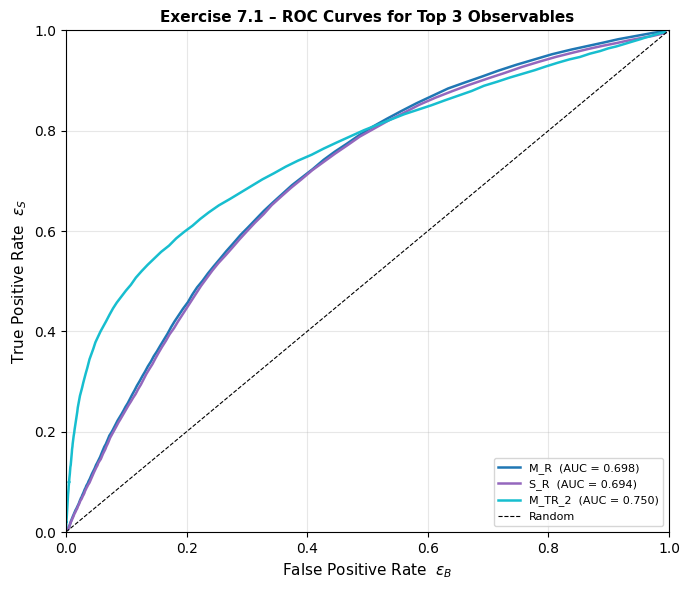


AUC values:
  M_R              AUC = 0.6979
  S_R              AUC = 0.6940
  M_TR_2           AUC = 0.7504


In [116]:
#7.1 and 7.2

from sklearn.metrics import auc

def plot_roc_curves(df_s, df_b, var_list, title="ROC Curves", ax=None):
    """
    Plot overlaid ROC curves for a list of observables.
    Uses the precomputed eff_cache (TPR, FPR) from Exercise 5.2.
    Computes AUC and reports it in the legend.

    Parameters
    ----------
    df_s, df_b : signal and background DataFrames (used to recompute if not cached)
    var_list   : list of variable names to plot
    title      : figure title
    ax         : optional existing matplotlib Axes to draw on

    Returns
    -------
    fig, ax, dict of {var: auc_value}
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.get_figure()

    colors = plt.cm.tab10(np.linspace(0, 0.9, len(var_list)))
    auc_dict = {}

    for var, color in zip(var_list, colors):
        if var in eff_cache:
            _, TPR, FPR = eff_cache[var]
        else:
            strat, mu = strategies[var]
            _, TPR, FPR = compute_efficiencies(df_s, df_b, var, strat, mu)

        # Sort by FPR for a proper curve, compute AUC
        order = np.argsort(FPR)
        fpr_s, tpr_s = FPR[order], TPR[order]
        auc_val = auc(fpr_s, tpr_s)
        # Flip if AUC < 0.5 (curve is below diagonal — just need to flip convention)
        if auc_val < 0.5:
            auc_val = 1 - auc_val
            fpr_s, tpr_s = 1 - fpr_s, 1 - tpr_s

        auc_dict[var] = auc_val
        ax.plot(fpr_s, tpr_s, color=color, linewidth=1.8,
                label=f"{var}  (AUC = {auc_val:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label="Random")
    ax.set_xlabel("False Positive Rate  $\\epsilon_B$", fontsize=11)
    ax.set_ylabel("True Positive Rate  $\\epsilon_S$", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.show()

    return fig, ax, auc_dict


# Top 3 observables by AUC (from significance plots: M_R, S_R, M_TR_2)
top3 = ["M_R", "S_R", "M_TR_2"]
_, _, aucs = plot_roc_curves(df_sig, df_bkg, top3,
                              title="Exercise 7.1 – ROC Curves for Top 3 Observables")

print("\nAUC values:")
for var, a in aucs.items():
    print(f"  {var:<15}  AUC = {a:.4f}")

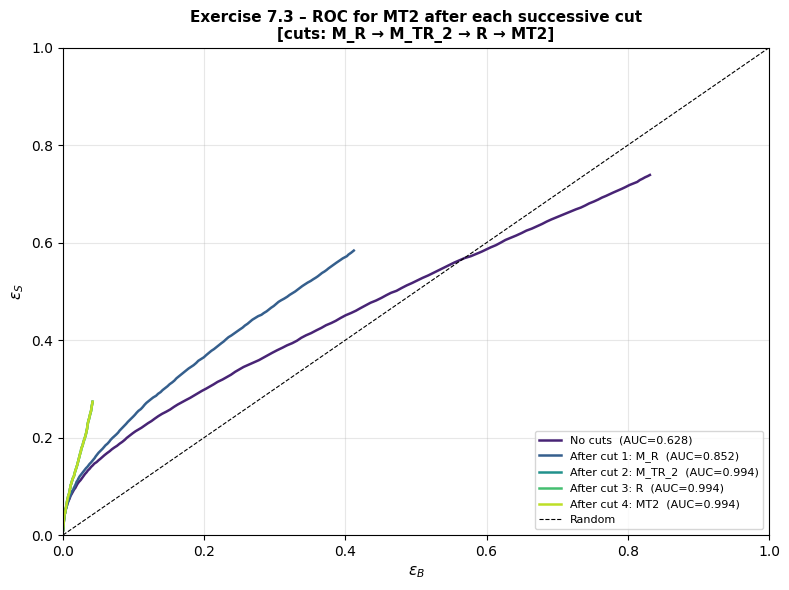

In [117]:
#7.3
def plot_roc_after_cuts(df_s, df_b, cut_list, eval_var, title="ROC after successive cuts"):
    """
    Evaluate the ROC curve for eval_var on the sample surviving after
    each successive cut in cut_list. Efficiencies are always relative
    to the original uncut sample so curves are directly comparable.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    n_steps = len(cut_list) + 1
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_steps))

    strat_eval, mu_eval = strategies[eval_var]
    sig_mask = np.ones(len(df_s), dtype=bool)
    bkg_mask = np.ones(len(df_b), dtype=bool)

    def _draw(label, color):
        ds = df_s[sig_mask]
        db = df_b[bkg_mask]
        _, TPR, FPR = compute_efficiencies(ds, db, eval_var, strat_eval, mu_eval)

        # Scale to original sample size
        eps_s0 = sig_mask.sum() / len(df_s)
        eps_b0 = bkg_mask.sum() / len(df_b)
        FPR_abs = FPR * eps_b0
        TPR_abs = TPR * eps_s0

        order = np.argsort(FPR_abs)
        fpr_s, tpr_s = FPR_abs[order], TPR_abs[order]
        auc_val = auc(fpr_s, tpr_s)
        if auc_val < 0.5:
            auc_val = 1 - auc_val
        ax.plot(fpr_s, tpr_s, color=color, linewidth=1.8,
                label=f"{label}  (AUC={auc_val:.3f})")

    _draw("No cuts", colors[0])

    for i, (var, strat_cut, mu_cut, xc) in enumerate(cut_list):
        sig_mask &= apply_cut(df_s[var].to_numpy(), strat_cut, mu_cut, xc)
        bkg_mask &= apply_cut(df_b[var].to_numpy(), strat_cut, mu_cut, xc)
        _draw(f"After cut {i+1}: {var}", colors[i + 1])

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label="Random")
    ax.set_xlabel(r"$\epsilon_B$", fontsize=11)
    ax.set_ylabel(r"$\epsilon_S$", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_roc_after_cuts(
    df_sig, df_bkg, cut_list_revised, eval_var="MT2",
    title="Exercise 7.3 – ROC for MT2 after each successive cut\n"
          "[cuts: M_R → M_TR_2 → R → MT2]")

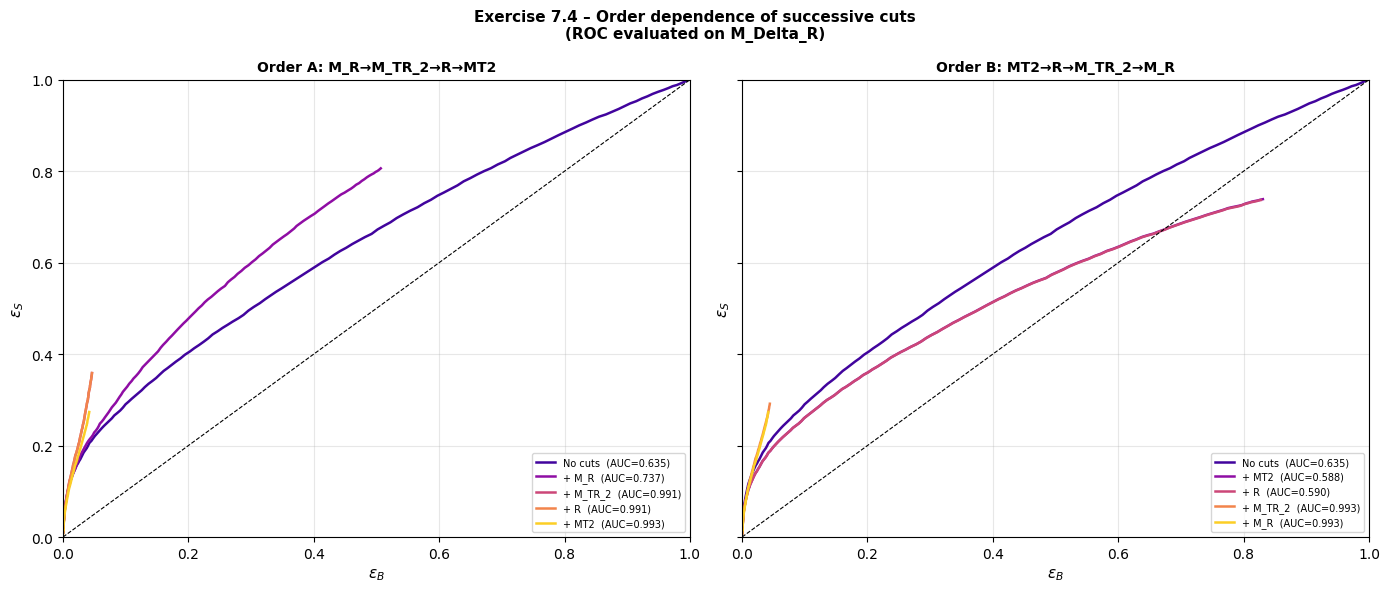

In [118]:
#7.4
# Two orderings of the same 4 cuts
order_A = ["M_R", "M_TR_2", "R", "MT2"]   # original
order_B = ["MT2", "R", "M_TR_2", "M_R"]   # reversed

cut_list_A = [(v, *chosen_cuts[v]) for v in order_A]
cut_list_B = [(v, *chosen_cuts[v]) for v in order_B]

# Evaluate ROC on a held-out variable not in the cut list: M_Delta_R
eval_var = "M_Delta_R"
strat_eval, mu_eval = strategies[eval_var]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (cut_list_ord, label_ord) in zip(
        axes, [(cut_list_A, "Order A: M_R→M_TR_2→R→MT2"),
               (cut_list_B, "Order B: MT2→R→M_TR_2→M_R")]):

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(cut_list_ord) + 1))
    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)

    def draw_roc(label, color):
        ds = df_sig[sig_mask]; db = df_bkg[bkg_mask]
        _, TPR, FPR = compute_efficiencies(ds, db, eval_var, strat_eval, mu_eval)
        eps_s0 = sig_mask.sum() / len(df_sig)
        eps_b0 = bkg_mask.sum() / len(df_bkg)
        TPR_abs, FPR_abs = TPR * eps_s0, FPR * eps_b0
        order = np.argsort(FPR_abs)
        fpr_s, tpr_s = FPR_abs[order], TPR_abs[order]
        auc_val = auc(fpr_s, tpr_s)
        if auc_val < 0.5: auc_val = 1 - auc_val
        ax.plot(fpr_s, tpr_s, color=color, linewidth=1.8,
                label=f"{label}  (AUC={auc_val:.3f})")

    draw_roc("No cuts", colors[0])
    for i, (var, strat_cut, mu_cut, xc) in enumerate(cut_list_ord):
        sig_mask &= apply_cut(df_sig[var].to_numpy(), strat_cut, mu_cut, xc)
        bkg_mask &= apply_cut(df_bkg[var].to_numpy(), strat_cut, mu_cut, xc)
        draw_roc(f"+ {var}", colors[i+1])

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel("$\\epsilon_B$", fontsize=11)
    ax.set_ylabel("$\\epsilon_S$", fontsize=11)
    ax.set_title(label_ord, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Exercise 7.4 – Order dependence of successive cuts\n"
             f"(ROC evaluated on {eval_var})",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [123]:
#8.1a

# Use all observables (excluding the label column)
obs = VarNames[1:]

X_sig = df_sig[obs].to_numpy()   # shape (n_sig, n_features)
X_bkg = df_bkg[obs].to_numpy()   # shape (n_bkg, n_features)

m1 = X_sig.mean(axis=0)   # signal mean vector
m2 = X_bkg.mean(axis=0)   # background mean vector

diff = (m2 - m1).reshape(-1, 1)   # column vector, shape (n_features, 1)

# Between-class scatter: S_B = (m2-m1)(m2-m1)^T
S_B = diff @ diff.T
print("S_B shape:", S_B.shape)

# Within-class scatter: S_W = sum over both classes of (x - m)(x - m)^T
# Equivalent to (n-1) * covariance matrix for each class, then summed
X_sig_c = X_sig - m1   # centered signal,     shape (n_sig, n_features)
X_bkg_c = X_bkg - m2   # centered background, shape (n_bkg, n_features)

S_W = X_sig_c.T @ X_sig_c + X_bkg_c.T @ X_bkg_c
print("S_W shape:", S_W.shape)

S_B shape: (18, 18)
S_W shape: (18, 18)


w shape: (18,)


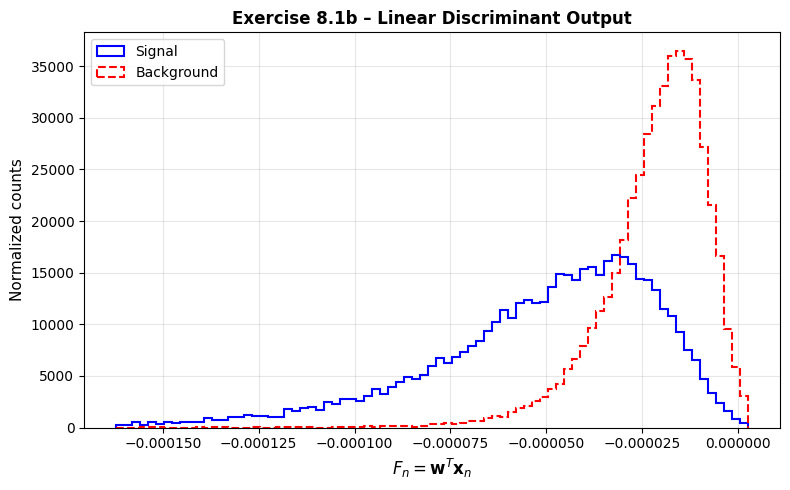


Signal     mean=-0.0001  std=0.0000
Background mean=-0.0000  std=0.0000


In [124]:
#8.1b

# w = S_W^{-1} (m2 - m1)
w = np.linalg.inv(S_W) @ diff.flatten()
print("w shape:", w.shape)

# Project each event onto w: F_n = w^T x_n
F_sig = X_sig @ w   # shape (n_sig,)
F_bkg = X_bkg @ w   # shape (n_bkg,)

# Plot distributions
fig, ax = plt.subplots(figsize=(8, 5))
lo = np.percentile(np.concatenate([F_sig, F_bkg]), 0.5)
hi = np.percentile(np.concatenate([F_sig, F_bkg]), 99.5)
bins = np.linspace(lo, hi, 80)

ax.hist(F_sig, bins=bins, histtype='step', color='blue',
        density=True, linewidth=1.5, label='Signal')
ax.hist(F_bkg, bins=bins, histtype='step', color='red',
        density=True, linewidth=1.5, linestyle='--', label='Background')

ax.set_xlabel(r"$F_n = \mathbf{w}^T \mathbf{x}_n$", fontsize=12)
ax.set_ylabel("Normalized counts", fontsize=11)
ax.set_title("Exercise 8.1b – Linear Discriminant Output", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSignal     mean={F_sig.mean():.4f}  std={F_sig.std():.4f}")
print(f"Background mean={F_bkg.mean():.4f}  std={F_bkg.std():.4f}")

In [126]:
# Rebuild dependencies from Exercise 7
from sklearn.metrics import auc

def compute_roc(df_s, df_b, var):
    if var in eff_cache:
        _, TPR, FPR = eff_cache[var]
    else:
        strat, mu = strategies[var]
        _, TPR, FPR = compute_efficiencies(df_s, df_b, var, strat, mu)

    order = np.argsort(FPR)
    fpr_s, tpr_s = FPR[order], TPR[order]
    auc_val = auc(fpr_s, tpr_s)
    if auc_val < 0.5:
        auc_val = 1 - auc_val
        fpr_s, tpr_s = 1 - fpr_s, 1 - tpr_s

    return fpr_s, tpr_s, auc_val

# top3 by AUC
all_aucs = {var: compute_roc(df_sig, df_bkg, var)[2] for var in VarNames[1:]}
top3 = sorted(all_aucs, key=all_aucs.get, reverse=True)[:3]
print("Top 3:", {v: f"{all_aucs[v]:.4f}" for v in top3})

Top 3: {'MET': '0.7627', 'l_1_pT': '0.7582', 'M_TR_2': '0.7504'}


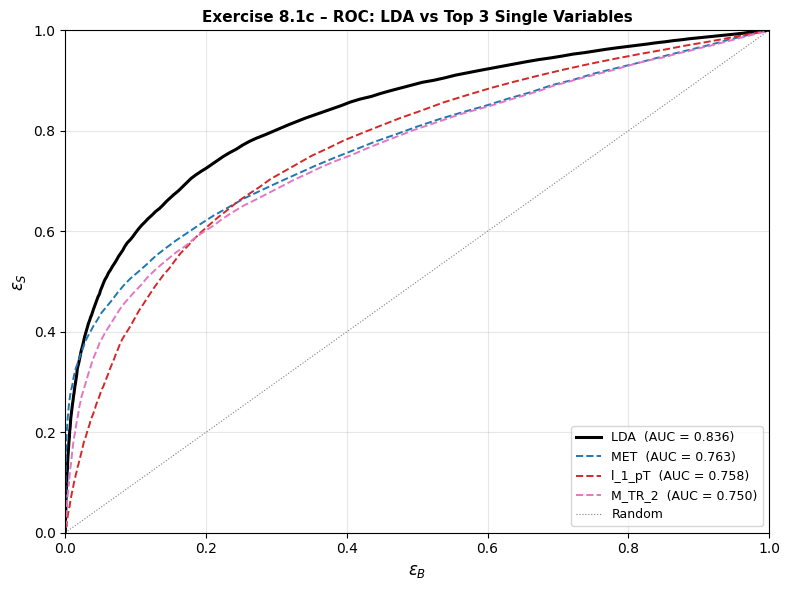

In [127]:
#8.1c

# Scan threshold on F and compute TPR / FPR
n_cuts = 500
thresholds = np.linspace(
    np.percentile(np.concatenate([F_sig, F_bkg]), 0.1),
    np.percentile(np.concatenate([F_sig, F_bkg]), 99.9),
    n_cuts)

TPR_lda = np.array([np.mean(F_sig > t) for t in thresholds])
FPR_lda = np.array([np.mean(F_bkg > t) for t in thresholds])

order = np.argsort(FPR_lda)
fpr_s, tpr_s = FPR_lda[order], TPR_lda[order]
auc_lda = auc(fpr_s, tpr_s)
if auc_lda < 0.5:
    auc_lda = 1 - auc_lda
    fpr_s, tpr_s = 1 - fpr_s, 1 - tpr_s

# Overlay with top 3 single-variable ROC curves for comparison
fig, ax = plt.subplots(figsize=(8, 6))

# LDA
ax.plot(fpr_s, tpr_s, 'k-', linewidth=2.2,
        label=f"LDA  (AUC = {auc_lda:.3f})")

# Top 3 single variables
colors = plt.cm.tab10(np.linspace(0, 0.6, 3))
for var, color in zip(top3, colors):
    fpr_v, tpr_v, auc_v = compute_roc(df_sig, df_bkg, var)
    ax.plot(fpr_v, tpr_v, color=color, linewidth=1.4, linestyle='--',
            label=f"{var}  (AUC = {auc_v:.3f})")

ax.plot([0, 1], [0, 1], 'gray', linewidth=0.8, linestyle=':', label="Random")
ax.set_xlabel(r"$\epsilon_B$", fontsize=12)
ax.set_ylabel(r"$\epsilon_S$", fontsize=12)
ax.set_title("Exercise 8.1c – ROC: LDA vs Top 3 Single Variables", fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()